# 🐝 Bee Optimum Placement Project
## Kenya Beekeeping Suitability Analysis — Full Notebook

**Pipeline Overview:**
1. Environment Setup & Imports
2. Configuration
3. Data Loading (NetCDF Climate + OSM Shapefiles)
4. Data Cleaning & Quality Control
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. ML Model Training (Random Forest + Gradient Boosting Ensemble)
8. Model Evaluation & Diagnostics
9. Suitability Prediction on Full Grid
10. Results Export
11. Interactive Map Generation

---
> **Data required:** ERA5 NetCDF climatology files + OSM Kenya shapefiles  
> **Output:** `outputs/` folder with CSV results, PNG charts, HTML maps

---
## 1. Environment Setup & Imports

In [1]:
# ── Standard library ─────────────────────────────────────
import os
import sys
import time
import warnings
import pickle
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Numerical / data ─────────────────────────────────────
import numpy as np
import pandas as pd
import xarray as xr

# ── Geospatial ────────────────────────────────────────────
import geopandas as gpd
from shapely.geometry import Point, box
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree

# ── Visualisation ─────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('husl')

# ── Machine learning ─────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score)
from sklearn.inspection import permutation_importance

# ── Interactive maps ─────────────────────────────────────
import folium
from folium.plugins import MiniMap, Fullscreen, MousePosition, MarkerCluster, HeatMap
from branca.colormap import LinearColormap

print('✅ All libraries imported successfully.')
print(f'   NumPy     {np.__version__}')
print(f'   Pandas    {pd.__version__}')
print(f'   GeoPandas {gpd.__version__}')
print(f'   xArray    {xr.__version__}')

✅ All libraries imported successfully.
   NumPy     1.26.4
   Pandas    2.2.2
   GeoPandas 1.1.3
   xArray    2025.6.1


---
## 2. Configuration

All paths, thresholds, weights, and hyperparameters are centralised here.  
**Edit `DATA_DIR` to match your local folder.**

In [2]:
# ── ⚠️  EDIT THIS PATH ────────────────────────────────────
DATA_DIR   = r"C:\Users\ZUPLO\Desktop\BEE PROJECT"
OUTPUT_DIR = os.path.join(DATA_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Kenya bounding box ────────────────────────────────────
KENYA_BOUNDS = dict(lat_min=-4.67, lat_max=4.62,
                    lon_min=33.91, lon_max=41.90)
KENYA_BOX    = box(KENYA_BOUNDS['lon_min'], KENYA_BOUNDS['lat_min'],
                   KENYA_BOUNDS['lon_max'], KENYA_BOUNDS['lat_max'])

# Grid resolution in degrees  (~0.1° ≈ 11 km)
GRID_RESOLUTION = 0.1

# ── NetCDF paths ─────────────────────────────────────────
NC_FILES = {
    'wind':          os.path.join(DATA_DIR,
        'climatology-sfcwind-monthly-mean_era5-x0.25_era5-x0.25-historical'
        '_climatology_mean_1991-2020.nc'),
    'temperature':   os.path.join(DATA_DIR,
        'climatology-tas-monthly-mean_era5-x0.25_era5-x0.25-historical'
        '_climatology_mean_1991-2020.nc'),
    'precipitation': os.path.join(DATA_DIR,
        'natvar-pr-seasonal-mean_era5-x0.25_era5-x0.25-historical'
        '_climatology_mean_1991-2020.nc'),
    'solar':         os.path.join(DATA_DIR,
        'natvar-rsds-seasonal-mean_era5-x0.25_era5-x0.25-historical'
        '_climatology_mean_1991-2020.nc'),
}

# ── Shapefile paths ───────────────────────────────────────
SHP_FILES = {
    'waterways':      os.path.join(DATA_DIR, 'gis_osm_waterways_free_1.shp'),
    'water':          os.path.join(DATA_DIR, 'gis_osm_water_a_free_1.shp'),
    'landuse':        os.path.join(DATA_DIR, 'gis_osm_landuse_a_free_1.shp'),
    'natural_areas':  os.path.join(DATA_DIR, 'gis_osm_natural_a_free_1.shp'),
    'natural_points': os.path.join(DATA_DIR, 'gis_osm_natural_free_1.shp'),
    'roads':          os.path.join(DATA_DIR, 'gis_osm_roads_free_1.shp'),
    'buildings':      os.path.join(DATA_DIR, 'gis_osm_buildings_a_free_1.shp'),
}

# ── Ecological thresholds ─────────────────────────────────
SCORING = {
    'temp_optimal_min':   20,    # °C
    'temp_optimal_max':   30,    # °C
    'temp_penalty_min':   10,    # °C — score → 0 below this
    'temp_penalty_max':   40,    # °C — score → 0 above this
    'wind_max':            6.7,  # m/s
    'solar_good':         200,   # W/m²
    'precip_optimal_min': 800,   # mm/yr
    'precip_optimal_max': 1200,  # mm/yr
    'precip_hard_min':    300,   # mm/yr
    'precip_hard_max':   2500,   # mm/yr
    'water_dist_optimal': 400,   # m
    'water_dist_max':    2000,   # m
    'road_dist_optimal': 1000,   # m
    'road_dist_max':    10000,   # m
    'building_buffer':    200,   # m — too urban inside this
    'building_penalty':  1000,   # m — partial penalty zone
}

# ── Feature weights (must sum to 1.0) ────────────────────
WEIGHTS = {
    'temperature':     0.22,
    'wind':            0.13,
    'solar':           0.12,
    'precipitation':   0.15,
    'water_proximity': 0.20,
    'land_cover':      0.12,
    'road_access':     0.06,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, 'Weights must sum to 1'

# ── ML config ─────────────────────────────────────────────
ML_CONFIG = {
    'n_estimators':      300,
    'max_depth':         None,
    'random_state':      42,
    'test_size':         0.2,
    'n_samples':         8000,
    'optimal_threshold': 0.65,
    'high_threshold':    0.80,
}

LANDCOVER_SCORES = {
    'forest': 1.0, 'wood': 1.0, 'scrub': 0.9, 'heath': 0.9,
    'grassland': 0.85, 'meadow': 0.85, 'wetland': 0.7,
    'orchard': 0.9, 'vineyard': 0.85,
    'farmland': 0.6, 'farm': 0.6, 'allotments': 0.7,
    'greenhouse_horticulture': 0.5,
    'residential': 0.3, 'commercial': 0.2, 'industrial': 0.1,
    'retail': 0.2, 'construction': 0.05,
    '_default': 0.4,
}

FEATURE_COLS = [
    'temp_c', 'wind_ms', 'solar_wm2', 'precip_mm',
    'water_dist_m', 'road_dist_m', 'building_dist_m',
    's_temperature', 's_wind', 's_solar', 's_precipitation',
    's_water', 's_road', 's_building', 's_land_cover',
]

print('✅ Configuration loaded.')
print(f'   Data dir   : {DATA_DIR}')
print(f'   Output dir : {OUTPUT_DIR}')
print(f'   Grid res   : {GRID_RESOLUTION}° (~{GRID_RESOLUTION*111:.0f} km)')

✅ Configuration loaded.
   Data dir   : C:\Users\ZUPLO\Desktop\BEE PROJECT
   Output dir : C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs
   Grid res   : 0.1° (~11 km)


---
## 3. Data Loading
### 3.1 Verify Files on Disk

In [3]:
def check_files(file_dict: dict, label: str):
    print(f'\n── {label} ──')
    missing = []
    for key, path in file_dict.items():
        exists = os.path.exists(path)
        size   = f"{os.path.getsize(path)/1e6:.1f} MB" if exists else '—'
        status = '✅' if exists else '❌ MISSING'
        print(f'  {status}  {key:20s}  {size:>10}  {os.path.basename(path)}')
        if not exists:
            missing.append(key)
    return missing

missing_nc  = check_files(NC_FILES,  'NetCDF Climate Files')
missing_shp = check_files(SHP_FILES, 'OSM Shapefiles')

total_missing = len(missing_nc) + len(missing_shp)
if total_missing:
    print(f'\n⚠️  {total_missing} file(s) missing — those layers will be skipped.')
else:
    print('\n✅ All files present.')


── NetCDF Climate Files ──
  ✅  wind                     49.9 MB  climatology-sfcwind-monthly-mean_era5-x0.25_era5-x0.25-historical_climatology_mean_1991-2020.nc
  ✅  temperature              49.9 MB  climatology-tas-monthly-mean_era5-x0.25_era5-x0.25-historical_climatology_mean_1991-2020.nc
  ✅  precipitation            49.9 MB  natvar-pr-seasonal-mean_era5-x0.25_era5-x0.25-historical_climatology_mean_1991-2020.nc
  ✅  solar                    49.9 MB  natvar-rsds-seasonal-mean_era5-x0.25_era5-x0.25-historical_climatology_mean_1991-2020.nc

── OSM Shapefiles ──
  ✅  waterways                41.7 MB  gis_osm_waterways_free_1.shp
  ✅  water                    18.5 MB  gis_osm_water_a_free_1.shp
  ✅  landuse                  54.8 MB  gis_osm_landuse_a_free_1.shp
  ✅  natural_areas             0.1 MB  gis_osm_natural_a_free_1.shp
  ✅  natural_points            0.8 MB  gis_osm_natural_free_1.shp
  ✅  roads                   268.9 MB  gis_osm_roads_free_1.shp
  ✅  buildings              12

### 3.2 Load NetCDF Climate Data

In [4]:
def _detect_coord_names(ds):
    """Detect lat/lon dimension names robustly."""
    lat_candidates = ['lat', 'latitude', 'y', 'nav_lat']
    lon_candidates = ['lon', 'longitude', 'x', 'nav_lon']
    lat = next((c for c in ds.coords if c.lower() in lat_candidates), None)
    lon = next((c for c in ds.coords if c.lower() in lon_candidates), None)
    if lat is None or lon is None:
        lat = next((d for d in ds.dims if d.lower() in lat_candidates), None)
        lon = next((d for d in ds.dims if d.lower() in lon_candidates), None)
    if lat is None or lon is None:
        raise ValueError(f'Cannot find lat/lon in dataset. Coords: {list(ds.coords)}')
    return lat, lon


def load_nc_annual_mean(key: str) -> xr.DataArray:
    """Load NetCDF → annual mean DataArray clipped to Kenya."""
    path = NC_FILES[key]
    if not os.path.exists(path):
        raise FileNotFoundError(f'Not found: {path}')

    ds = xr.open_dataset(path)
    lat_name, lon_name = _detect_coord_names(ds)
    var_name = [v for v in ds.data_vars][0]
    da = ds[var_name].rename({lat_name: 'lat', lon_name: 'lon'})

    # Clip to Kenya
    lat_mask = (da['lat'] >= KENYA_BOUNDS['lat_min']) & (da['lat'] <= KENYA_BOUNDS['lat_max'])
    lon_mask = (da['lon'] >= KENYA_BOUNDS['lon_min']) & (da['lon'] <= KENYA_BOUNDS['lon_max'])
    da = da.isel(lat=lat_mask, lon=lon_mask)

    # Collapse time dims → annual mean
    time_dims = [d for d in da.dims if d.lower() in ('time', 'month', 'season', 'valid_time', 't')]
    for td in time_dims:
        da = da.mean(dim=td)

    # Unit conversions
    if key == 'temperature' and float(da.mean()) > 100:
        da = da - 273.15
        da.attrs['units'] = 'degC'
    if key == 'precipitation':
        units = da.attrs.get('units', '').lower()
        mean_val = float(da.mean())
        if 'kg' in units or mean_val < 10:
            da = da * 86_400 * 365
        elif mean_val < 100:
            da = da * 365
        da.attrs['units'] = 'mm/yr'
    if key == 'wind':
        da.attrs['units'] = 'm/s'
    if key == 'solar':
        da.attrs['units'] = 'W/m2'

    return da


# Load all climate layers
print('Loading climate datasets…')
climate = {}
for key in ('wind', 'temperature', 'precipitation', 'solar'):
    try:
        climate[key] = load_nc_annual_mean(key)
        print(f'  ✅ {key:14s} → shape={climate[key].shape}  '
              f'min={float(climate[key].min()):.2f}  '
              f'max={float(climate[key].max()):.2f}  '
              f'units={climate[key].attrs.get("units", "?")} ')
    except FileNotFoundError as e:
        print(f'  ⚠️  {key}: {e}')
        climate[key] = None

print('\n✅ Climate data loading complete.')

Loading climate datasets…
  ✅ wind           → shape=(37, 32)  min=0.38  max=6.82  units=m/s 
  ✅ temperature    → shape=(37, 32)  min=13.46  max=30.78  units=? 
  ✅ precipitation  → shape=(37, 32)  min=3428.53  max=186656.77  units=mm/yr 
  ✅ solar          → shape=(37, 32)  min=6.17  max=12.71  units=W/m2 

✅ Climate data loading complete.


### 3.3 Load OSM Spatial Data

In [5]:
def _load_shp(key: str, columns: list = None, query: str = None) -> gpd.GeoDataFrame:
    """Load shapefile, reproject to EPSG:4326, clip to Kenya bbox."""
    path = SHP_FILES[key]
    if not os.path.exists(path):
        print(f'  ⚠️  Missing: {key}')
        return gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')

    gdf = gpd.read_file(path, bbox=(
        KENYA_BOUNDS['lon_min'], KENYA_BOUNDS['lat_min'],
        KENYA_BOUNDS['lon_max'], KENYA_BOUNDS['lat_max'],
    ))
    if gdf.crs is None:
        gdf = gdf.set_crs('EPSG:4326')
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs('EPSG:4326')
    if query:
        try:
            gdf = gdf.query(query)
        except Exception:
            pass
    if columns:
        keep = [c for c in columns if c in gdf.columns] + ['geometry']
        gdf = gdf[keep]
    return gdf


print('Loading spatial shapefiles…')
t0 = time.time()

water_a   = _load_shp('water',          columns=['fclass', 'name'])
waterways = _load_shp('waterways',      columns=['fclass', 'name'])
water_all = gpd.GeoDataFrame(pd.concat([water_a, waterways], ignore_index=True), crs='EPSG:4326')
print(f'  ✅ Water features  : {len(water_all):,} rows')

landuse   = _load_shp('landuse',        columns=['fclass', 'name'])
print(f'  ✅ Land use        : {len(landuse):,} rows')

nat_a     = _load_shp('natural_areas',  columns=['fclass', 'name'])
nat_p     = _load_shp('natural_points', columns=['fclass', 'name'])
natural   = gpd.GeoDataFrame(pd.concat([nat_a, nat_p], ignore_index=True), crs='EPSG:4326')
print(f'  ✅ Natural areas   : {len(natural):,} rows')

road_types = ['motorway','trunk','primary','secondary','tertiary',
              'unclassified','residential','motorway_link','trunk_link','primary_link']
roads     = _load_shp('roads',          columns=['fclass', 'name'])
roads     = roads[roads['fclass'].isin(road_types)] if 'fclass' in roads.columns else roads
print(f'  ✅ Roads           : {len(roads):,} rows')

buildings = _load_shp('buildings',      columns=['fclass', 'type'])
print(f'  ✅ Buildings       : {len(buildings):,} rows')

spatial = {
    'water': water_all, 'landuse': landuse, 'natural': natural,
    'roads': roads, 'buildings': buildings,
}
print(f'\n✅ Shapefiles loaded in {time.time()-t0:.1f}s')

Loading spatial shapefiles…
  ✅ Water features  : 64,485 rows
  ✅ Land use        : 117,399 rows
  ✅ Natural areas   : 29,233 rows
  ✅ Roads           : 423,963 rows
  ✅ Buildings       : 7,866,727 rows

✅ Shapefiles loaded in 591.6s


---
## 4. Data Cleaning & Quality Control
### 4.1 Climate Data QC

In [6]:
def qc_climate_layer(key: str, da: xr.DataArray) -> dict:
    """Return QC statistics for a single climate DataArray."""
    if da is None:
        return {'key': key, 'status': 'MISSING', 'n_total': 0, 'n_nan': 0, 'pct_nan': 100}
    vals = da.values.ravel()
    n_total = len(vals)
    n_nan   = int(np.isnan(vals).sum())
    n_inf   = int(np.isinf(vals).sum())
    valid   = vals[np.isfinite(vals)]
    return {
        'key':       key,
        'status':    'OK' if n_nan == 0 else 'HAS_NaN',
        'shape':     str(da.shape),
        'n_total':   n_total,
        'n_nan':     n_nan,
        'n_inf':     n_inf,
        'pct_nan':   round(100 * n_nan / n_total, 2),
        'min':       round(float(valid.min()), 3) if len(valid) else None,
        'max':       round(float(valid.max()), 3) if len(valid) else None,
        'mean':      round(float(valid.mean()), 3) if len(valid) else None,
        'std':       round(float(valid.std()), 3) if len(valid) else None,
        'units':     da.attrs.get('units', '?'),
    }

# Expected physical ranges for sanity checks
EXPECTED_RANGES = {
    'temperature':   (-10, 50),
    'wind':          (0, 30),
    'precipitation': (0, 5000),
    'solar':         (0, 500),
}

climate_qc = []
for key, da in climate.items():
    stats = qc_climate_layer(key, da)
    climate_qc.append(stats)

    if da is not None and stats['min'] is not None:
        lo, hi = EXPECTED_RANGES.get(key, (-1e9, 1e9))
        if stats['min'] < lo or stats['max'] > hi:
            print(f'  ⚠️  {key}: range [{stats["min"]}, {stats["max"]}] outside expected [{lo}, {hi}]')
        else:
            print(f'  ✅ {key}: range [{stats["min"]}, {stats["max"]}] — OK')

climate_qc_df = pd.DataFrame(climate_qc)
display(climate_qc_df[['key','status','shape','pct_nan','min','max','mean','std','units']])

  ✅ wind: range [0.38, 6.824] — OK
  ✅ temperature: range [13.463, 30.777] — OK
  ⚠️  precipitation: range [3428.535, 186656.766] outside expected [0, 5000]
  ✅ solar: range [6.17, 12.71] — OK


,key,status,shape,pct_nan,min,max,mean,std,units
0,wind,OK,"(37, 32)",0.0,0.380,6.824,3.162,1.465,m/s
1,temperature,OK,"(37, 32)",0.0,13.463,30.777,24.894,3.599,?
2,precipitation,OK,"(37, 32)",0.0,3428.535,186656.766,15106.359,10511.411,mm/yr
3,solar,OK,"(37, 32)",0.0,6.170,12.710,8.907,1.231,W/m2


### 4.2 Shapefile Data Cleaning

In [7]:
def clean_shapefile(gdf: gpd.GeoDataFrame, layer_name: str) -> gpd.GeoDataFrame:
    """Remove nulls, duplicates, invalid geometries, and fix CRS."""
    n_orig = len(gdf)
    issues = []

    # Drop rows with null geometry
    n_null_geom = gdf.geometry.isna().sum()
    if n_null_geom:
        gdf = gdf[~gdf.geometry.isna()]
        issues.append(f'{n_null_geom} null geometries')

    # Drop geometrically invalid rows
    invalid_mask = ~gdf.geometry.is_valid
    n_invalid    = invalid_mask.sum()
    if n_invalid:
        # Attempt buffer(0) fix first
        gdf.loc[invalid_mask, 'geometry'] = gdf.loc[invalid_mask, 'geometry'].buffer(0)
        still_invalid = ~gdf.geometry.is_valid
        if still_invalid.sum():
            gdf = gdf[gdf.geometry.is_valid]
        issues.append(f'{n_invalid} invalid geometries (fixed/removed)')

    # Drop empty geometries
    n_empty = gdf.geometry.is_empty.sum()
    if n_empty:
        gdf = gdf[~gdf.geometry.is_empty]
        issues.append(f'{n_empty} empty geometries')

    # Drop full-row duplicates
    n_dup = gdf.duplicated().sum()
    if n_dup:
        gdf = gdf.drop_duplicates()
        issues.append(f'{n_dup} duplicates')

    # Standardise fclass to lowercase
    if 'fclass' in gdf.columns:
        gdf['fclass'] = gdf['fclass'].astype(str).str.lower().str.strip()

    n_kept   = len(gdf)
    n_dropped = n_orig - n_kept
    summary   = ', '.join(issues) if issues else 'none'
    print(f'  {layer_name:15s} : {n_orig:>7,} → {n_kept:>7,} kept  '
          f'(dropped {n_dropped:,} — {summary})')
    return gdf.reset_index(drop=True)


print('Cleaning shapefiles…')
for key in spatial:
    spatial[key] = clean_shapefile(spatial[key], key)

print('\n✅ Shapefiles cleaned.')

Cleaning shapefiles…
  water           :  64,485 →  64,483 kept  (dropped 2 — 2 duplicates)
  landuse         : 117,399 → 117,390 kept  (dropped 9 — 9 duplicates)
  natural         :  29,233 →  29,187 kept  (dropped 46 — 46 duplicates)
  roads           : 423,963 → 423,963 kept  (dropped 0 — none)
  buildings       : 7,866,727 → 7,865,420 kept  (dropped 1,307 — 1307 duplicates)

✅ Shapefiles cleaned.


### 4.3 Land-Use Category Audit

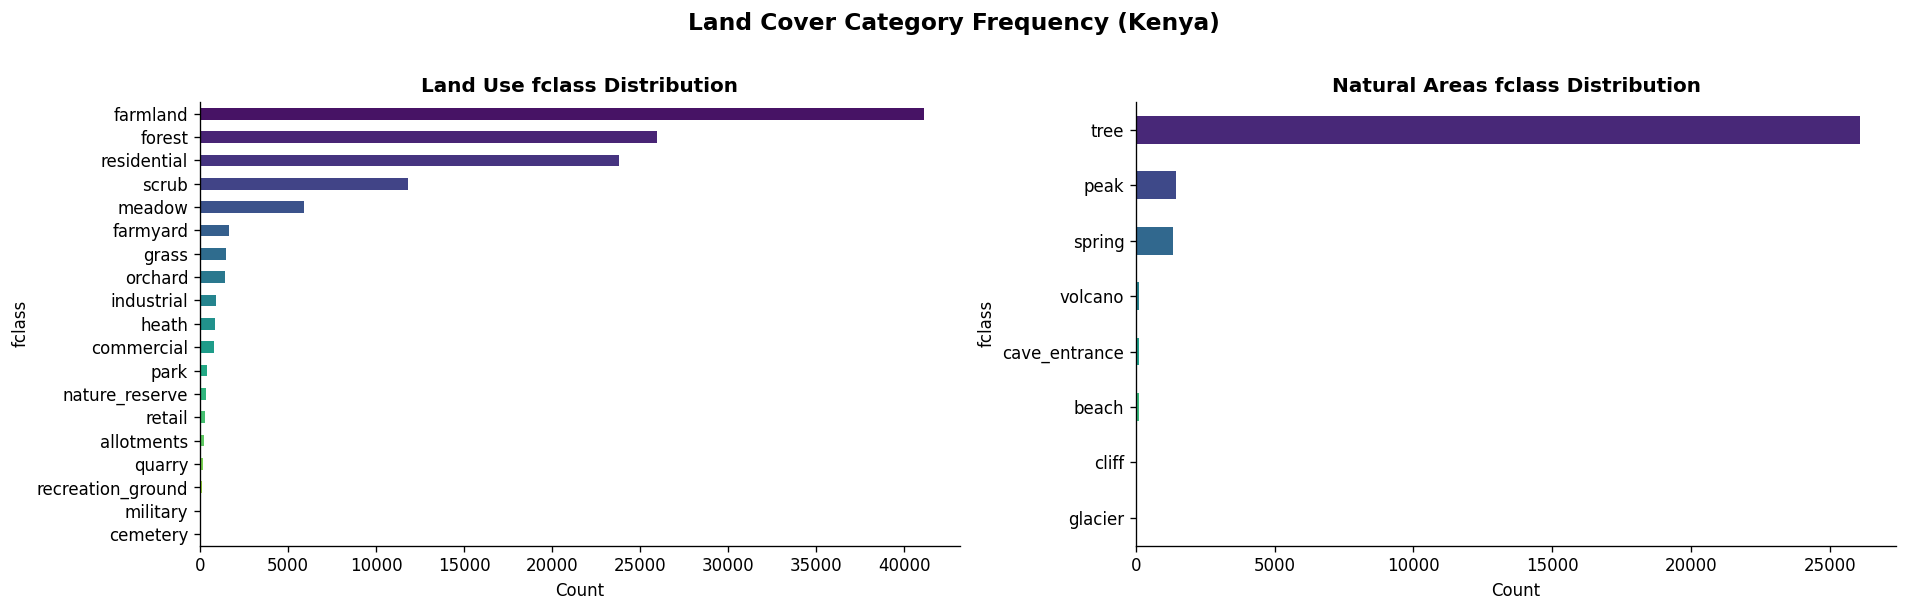

Saved → landcover_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (gdf, title) in zip(axes, [
    (spatial['landuse'], 'Land Use fclass Distribution'),
    (spatial['natural'], 'Natural Areas fclass Distribution'),
]):
    if 'fclass' in gdf.columns and len(gdf):
        counts = gdf['fclass'].value_counts().head(20)
        counts.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(counts)))
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Count')
        ax.invert_yaxis()
    else:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
        ax.set_title(title)

plt.suptitle('Land Cover Category Frequency (Kenya)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'landcover_distribution.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print('Saved → landcover_distribution.png')

---
## 5. Exploratory Data Analysis
### 5.1 Climate Variable Spatial Plots

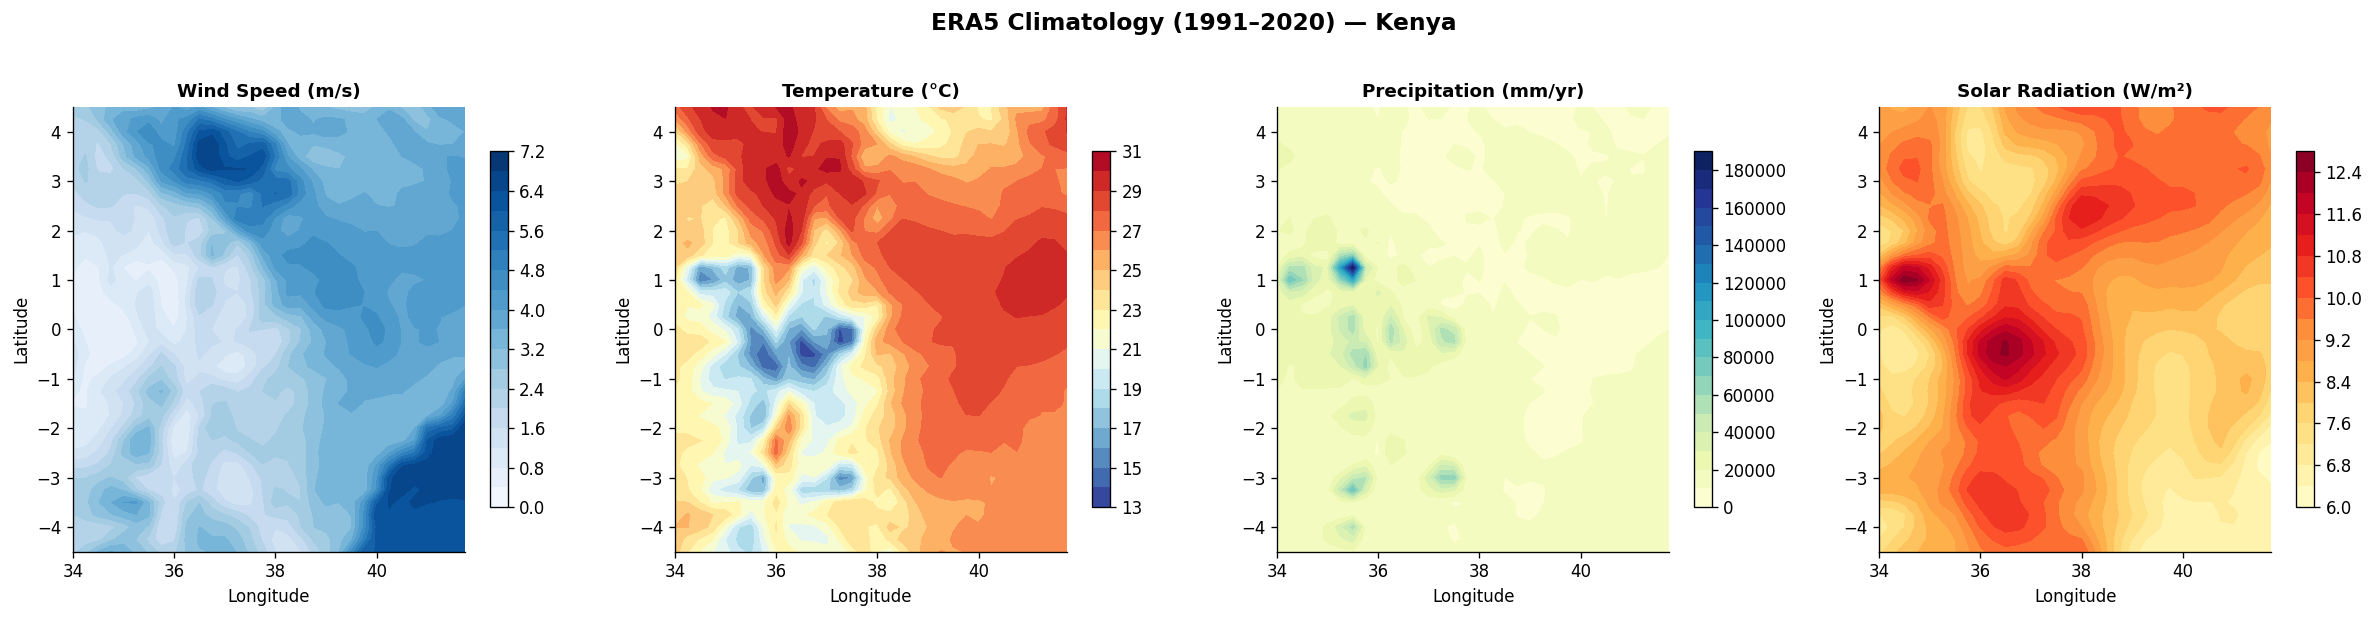

Saved → climate_spatial_overview.png


In [55]:
labels = {
    'temperature':   ('Temperature (°C)', 'RdYlBu_r'),
    'wind':          ('Wind Speed (m/s)',  'Blues'),
    'precipitation': ('Precipitation (mm/yr)', 'YlGnBu'),
    'solar':         ('Solar Radiation (W/m²)', 'YlOrRd'),
}

available = [(k, v) for k, v in climate.items() if v is not None]
n_plots   = len(available)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

for ax, (key, da) in zip(axes, available):
    title, cmap = labels.get(key, (key, 'viridis'))
    vals = da.values
    lons = da['lon'].values
    lats = da['lat'].values
    cf = ax.contourf(lons, lats, vals, levels=20, cmap=cmap)
    plt.colorbar(cf, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_facecolor('#f0f0f0')

plt.suptitle('ERA5 Climatology (1991–2020) — Kenya', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'climate_spatial_overview.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print('Saved → climate_spatial_overview.png')

### 5.2 Climate Variable Distributions

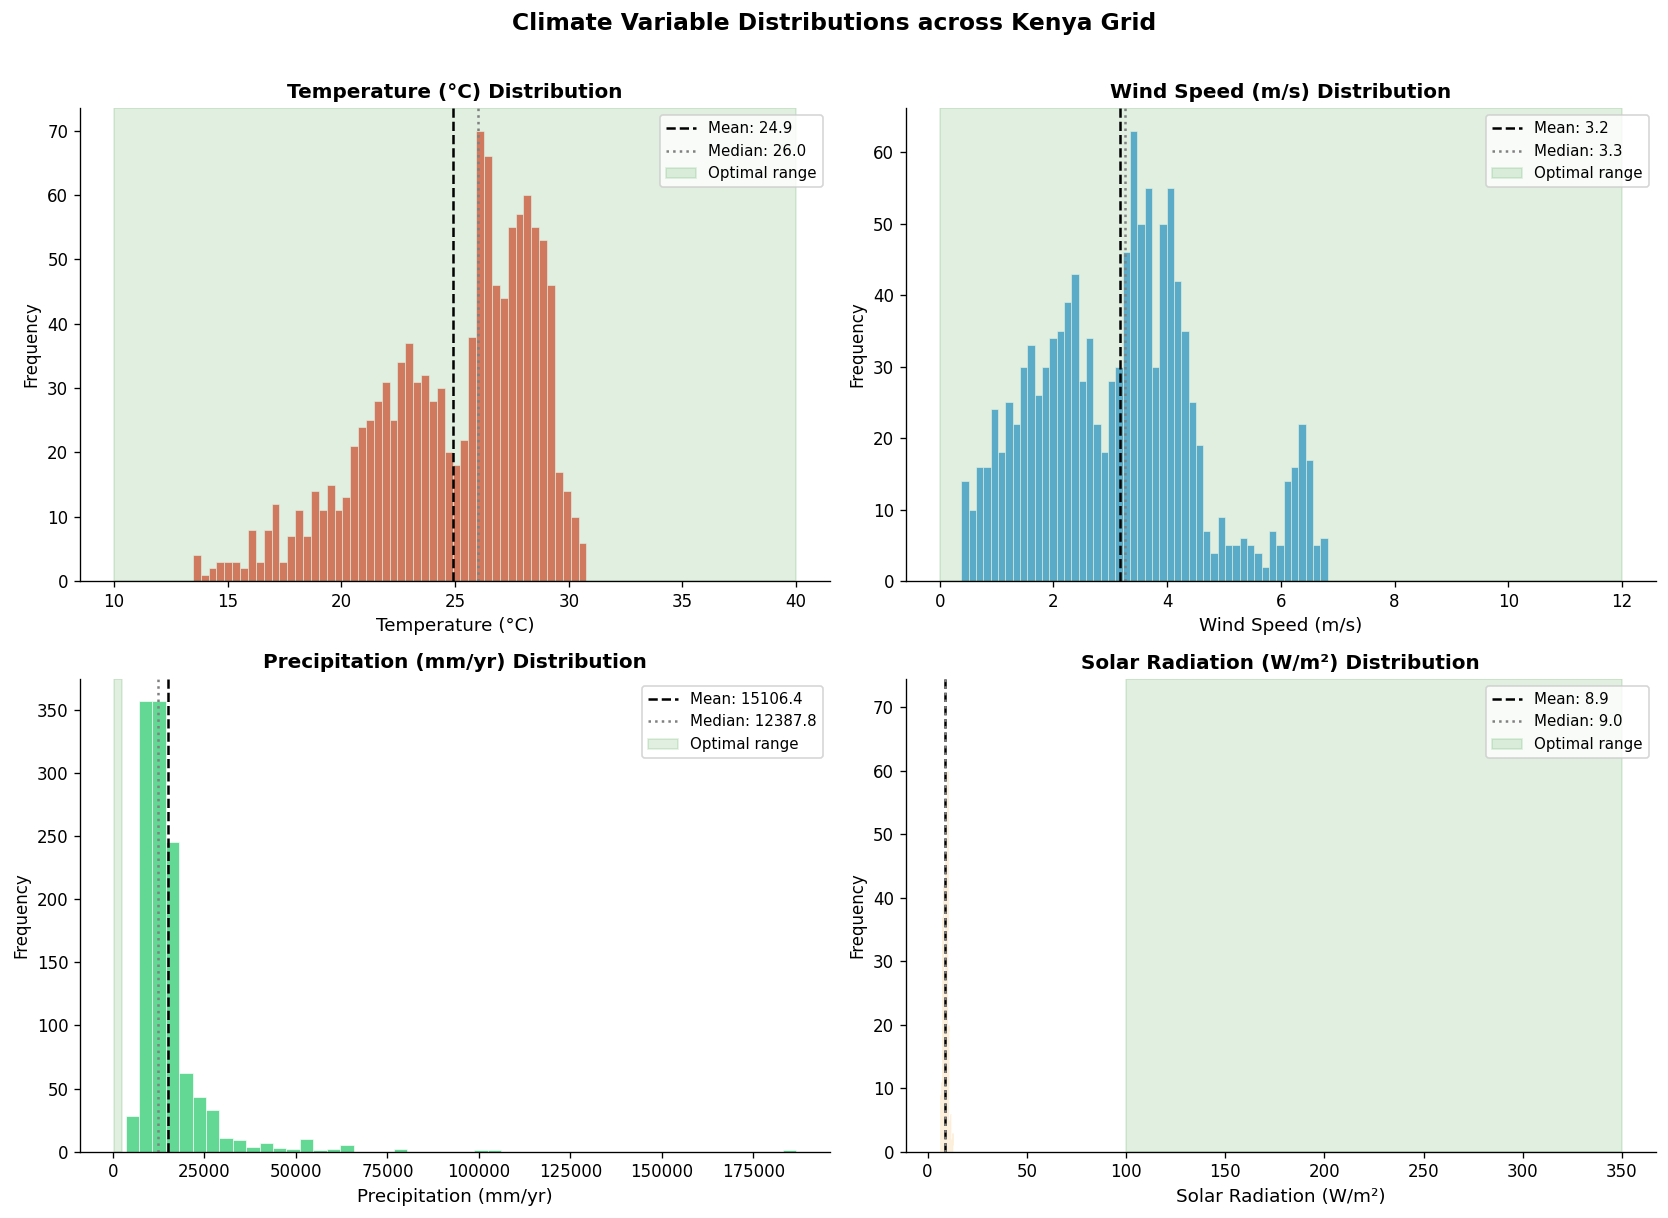

Saved → climate_distributions.png


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

plot_info = [
    ('temperature',   'Temperature (°C)',     '#e74c3c', (10, 40)),
    ('wind',          'Wind Speed (m/s)',      '#3498db', (0, 12)),
    ('precipitation', 'Precipitation (mm/yr)', '#2ecc71', (300, 2500)),
    ('solar',         'Solar Radiation (W/m²)','#f39c12', (100, 350)),
]

for ax, (key, xlabel, color, opt_range) in zip(axes, plot_info):
    da = climate.get(key)
    if da is None:
        ax.text(0.5, 0.5, 'Data unavailable', transform=ax.transAxes, ha='center')
        continue

    vals = da.values.ravel()
    vals = vals[np.isfinite(vals)]

    ax.hist(vals, bins=50, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(np.mean(vals), color='black',  linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(vals):.1f}')
    ax.axvline(np.median(vals), color='grey', linestyle=':',  linewidth=1.5, label=f'Median: {np.median(vals):.1f}')

    # Optimal zone shading
    ax.axvspan(opt_range[0], opt_range[1], alpha=0.12, color='green', label='Optimal range')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{xlabel} Distribution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Climate Variable Distributions across Kenya Grid', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'climate_distributions.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print('Saved → climate_distributions.png')

---
## 6. Feature Engineering
### 6.1 Build Kenya Grid

In [11]:
def make_grid() -> gpd.GeoDataFrame:
    """Regular grid of points covering Kenya at GRID_RESOLUTION."""
    lats = np.arange(KENYA_BOUNDS['lat_min'] + GRID_RESOLUTION / 2,
                     KENYA_BOUNDS['lat_max'], GRID_RESOLUTION)
    lons = np.arange(KENYA_BOUNDS['lon_min'] + GRID_RESOLUTION / 2,
                     KENYA_BOUNDS['lon_max'], GRID_RESOLUTION)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    df = pd.DataFrame({'lat': lat_grid.ravel(), 'lon': lon_grid.ravel()})
    df['geometry'] = [Point(xy) for xy in zip(df['lon'], df['lat'])]
    gdf = gpd.GeoDataFrame(df, crs='EPSG:4326')
    print(f'Grid: {len(gdf):,} points ({len(lats)} rows × {len(lons)} cols)')
    return gdf

gdf = make_grid()

Grid: 7,440 points (93 rows × 80 cols)


### 6.2 Climate Interpolation onto Grid

In [12]:
def _build_interpolator(da: xr.DataArray) -> RegularGridInterpolator:
    lats = da['lat'].values
    lons = da['lon'].values
    vals = da.values
    if lats[0] > lats[-1]:
        lats, vals = lats[::-1], vals[::-1, :]
    if lons[0] > lons[-1]:
        lons, vals = lons[::-1], vals[:, ::-1]
    return RegularGridInterpolator((lats, lons), vals,
                                   method='linear', bounds_error=False,
                                   fill_value=np.nan)


def extract_climate_features(gdf, climate):
    pts = np.column_stack([gdf['lat'].values, gdf['lon'].values])
    for key, col in [('temperature','temp_c'), ('wind','wind_ms'),
                     ('precipitation','precip_mm'), ('solar','solar_wm2')]:
        da = climate.get(key)
        if da is None:
            gdf[col] = np.nan
        else:
            gdf[col] = _build_interpolator(da)(pts)
        nan_pct = gdf[col].isna().mean() * 100
        print(f'  {col:15s}: min={gdf[col].min():.2f}  '
              f'max={gdf[col].max():.2f}  NaN={nan_pct:.1f}%')
    return gdf


print('Interpolating climate onto grid…')
gdf = extract_climate_features(gdf, climate)

Interpolating climate onto grid…
  temp_c         : min=13.57  max=30.71  NaN=6.9%
  wind_ms        : min=0.40  max=6.74  NaN=6.9%
  precip_mm      : min=3825.68  max=160280.52  NaN=6.9%
  solar_wm2      : min=6.24  max=12.54  NaN=6.9%


### 6.3 Spatial Distance Features

In [13]:
def _projected_coords(gdf, crs='EPSG:32737'):
    g = gdf.to_crs(crs)
    return np.column_stack([g.geometry.x, g.geometry.y])

def _feature_coords(feature_gdf, crs='EPSG:32737'):
    g = feature_gdf.copy().to_crs(crs)
    pts = g.geometry.centroid
    return np.column_stack([pts.x, pts.y])

def min_distance_m(grid_gdf, feature_gdf, crs='EPSG:32737'):
    """KDTree nearest-neighbour distance (metres)."""
    if feature_gdf is None or len(feature_gdf) == 0:
        return np.full(len(grid_gdf), np.nan)
    grid_pts = _projected_coords(grid_gdf, crs)
    feat_pts = _feature_coords(feature_gdf, crs)
    feat_pts = feat_pts[np.isfinite(feat_pts).all(axis=1)]
    if len(feat_pts) == 0:
        return np.full(len(grid_gdf), np.nan)
    dist, _ = cKDTree(feat_pts).query(grid_pts)
    return dist


print('Computing spatial distance features (this may take a few minutes)…')
t0 = time.time()

print('  [1/3] Water proximity…')
gdf['water_dist_m']    = min_distance_m(gdf, spatial['water'])

print('  [2/3] Road proximity…')
gdf['road_dist_m']     = min_distance_m(gdf, spatial['roads'])

print('  [3/3] Building proximity…')
gdf['building_dist_m'] = min_distance_m(gdf, spatial['buildings'])

print(f'\n  → Done in {time.time()-t0:.1f}s')

for col in ['water_dist_m', 'road_dist_m', 'building_dist_m']:
    print(f'  {col:20s}: min={gdf[col].min():.0f}m  '
          f'max={gdf[col].max():.0f}m  '
          f'median={gdf[col].median():.0f}m')

Computing spatial distance features (this may take a few minutes)…
  [1/3] Water proximity…
  [2/3] Road proximity…
  [3/3] Building proximity…

  → Done in 62.6s
  water_dist_m        : min=3m  max=339998m  median=9186m
  road_dist_m         : min=13m  max=345130m  median=7944m
  building_dist_m     : min=1m  max=353617m  median=12857m


### 6.4 Land-Cover Scoring

In [53]:
def extract_landcover_score(grid_gdf, landuse_gdf, natural_gdf):
    """Spatial join → land cover score per grid point."""
    combined = gpd.GeoDataFrame(
        pd.concat([landuse_gdf, natural_gdf], ignore_index=True), crs='EPSG:4326')
    if len(combined) == 0:
        return np.full(len(grid_gdf), 0.4)

    joined = gpd.sjoin_nearest(
        grid_gdf[['geometry']],
        combined[['fclass', 'geometry']].rename(columns={'fclass': 'lc_fclass'}),
        how='left', max_distance=0.5, distance_col='_dist'
    )
    joined = joined[~joined.index.duplicated(keep='first')]

    def score_fc(fc):
        if pd.isna(fc):
            return LANDCOVER_SCORES['_default']
        return LANDCOVER_SCORES.get(str(fc).lower(), LANDCOVER_SCORES['_default'])

    return joined['lc_fclass'].apply(score_fc).values


print('Computing land-cover scores…')
gdf['land_cover_score'] = extract_landcover_score(
    gdf, spatial['landuse'], spatial['natural'])
print(f'  Land-cover score: min={gdf["land_cover_score"].min():.2f}  '
      f'max={gdf["land_cover_score"].max():.2f}  '
      f'mean={gdf["land_cover_score"].mean():.2f}')

Computing land-cover scores…
  Land-cover score: min=0.10  max=1.00  mean=0.48


### 6.5 Individual Suitability Scores

In [52]:
def score_temperature(temp_c):
    s = SCORING
    score = np.where(
        (temp_c >= s['temp_optimal_min']) & (temp_c <= s['temp_optimal_max']), 1.0,
        np.where(temp_c < s['temp_optimal_min'],
                 np.clip((temp_c - s['temp_penalty_min']) /
                         (s['temp_optimal_min'] - s['temp_penalty_min']), 0, 1),
                 np.clip(1 - (temp_c - s['temp_optimal_max']) /
                         (s['temp_penalty_max'] - s['temp_optimal_max']), 0, 1)))
    return np.where(np.isnan(temp_c), 0.5, score)

def score_wind(wind_ms):
    score = np.where(wind_ms <= SCORING['wind_max'], 1.0,
                     np.clip(1 - (wind_ms - SCORING['wind_max']) / SCORING['wind_max'], 0, 1))
    return np.where(np.isnan(wind_ms), 0.5, score)

def score_solar(solar_wm2):
    mn, mx = float(np.nanmin(solar_wm2)), float(np.nanmax(solar_wm2))
    score = (solar_wm2 - mn) / (mx - mn) if mx > mn else np.full_like(solar_wm2, 0.5)
    return np.where(np.isnan(solar_wm2), 0.5, np.clip(score, 0, 1))

def score_precipitation(precip_mm):
    s = SCORING
    score = np.where(
        (precip_mm >= s['precip_optimal_min']) & (precip_mm <= s['precip_optimal_max']), 1.0,
        np.where(precip_mm < s['precip_optimal_min'],
                 np.clip((precip_mm - s['precip_hard_min']) /
                         (s['precip_optimal_min'] - s['precip_hard_min']), 0, 1),
                 np.clip(1 - (precip_mm - s['precip_optimal_max']) /
                         (s['precip_hard_max'] - s['precip_optimal_max']), 0, 1)))
    return np.where(np.isnan(precip_mm), 0.5, score)

def score_water_proximity(dist_m):
    opt, hard = SCORING['water_dist_optimal'], SCORING['water_dist_max']
    score = np.where(dist_m <= opt, 1.0,
                     np.clip(1 - (dist_m - opt) / (hard - opt), 0, 1))
    return np.where(np.isnan(dist_m), 0.3, score)

def score_road_access(dist_m):
    opt, hard = SCORING['road_dist_optimal'], SCORING['road_dist_max']
    score = np.where(dist_m <= opt, 1.0,
                     np.clip(1 - (dist_m - opt) / (hard - opt), 0, 1))
    return np.where(np.isnan(dist_m), 0.3, score)

def score_building_penalty(dist_m):
    buf, pen = SCORING['building_buffer'], SCORING['building_penalty']
    score = np.where(dist_m >= pen, 1.0,
                     np.where(dist_m < buf, 0.0,
                              (dist_m - buf) / (pen - buf)))
    return np.where(np.isnan(dist_m), 0.8, np.clip(score, 0, 1))


print('Computing individual suitability scores…')
gdf['s_temperature']   = score_temperature(gdf['temp_c'].values)
gdf['s_wind']          = score_wind(gdf['wind_ms'].values)
gdf['s_solar']         = score_solar(gdf['solar_wm2'].values)
gdf['s_precipitation'] = score_precipitation(gdf['precip_mm'].values)
gdf['s_water']         = score_water_proximity(gdf['water_dist_m'].values)
gdf['s_road']          = score_road_access(gdf['road_dist_m'].values)
gdf['s_building']      = score_building_penalty(gdf['building_dist_m'].values)
gdf['s_land_cover']    = gdf['land_cover_score']

# Weighted composite score
W = WEIGHTS
gdf['suitability'] = (
    W['temperature']     * gdf['s_temperature']  +
    W['wind']            * gdf['s_wind']          +
    W['solar']           * gdf['s_solar']         +
    W['precipitation']   * gdf['s_precipitation'] +
    W['water_proximity'] * gdf['s_water']         +
    W['land_cover']      * gdf['s_land_cover']    +
    W['road_access']     * gdf['s_road']
) * gdf['s_building']
gdf['suitability'] = gdf['suitability'].clip(0, 1)

print(f'\n✅ Composite suitability: '
      f'min={gdf["suitability"].min():.3f}  '
      f'max={gdf["suitability"].max():.3f}  '
      f'mean={gdf["suitability"].mean():.3f}')

Computing individual suitability scores…

✅ Composite suitability: min=0.000  max=0.794  mean=0.440


### 6.6 Feature Correlation Matrix

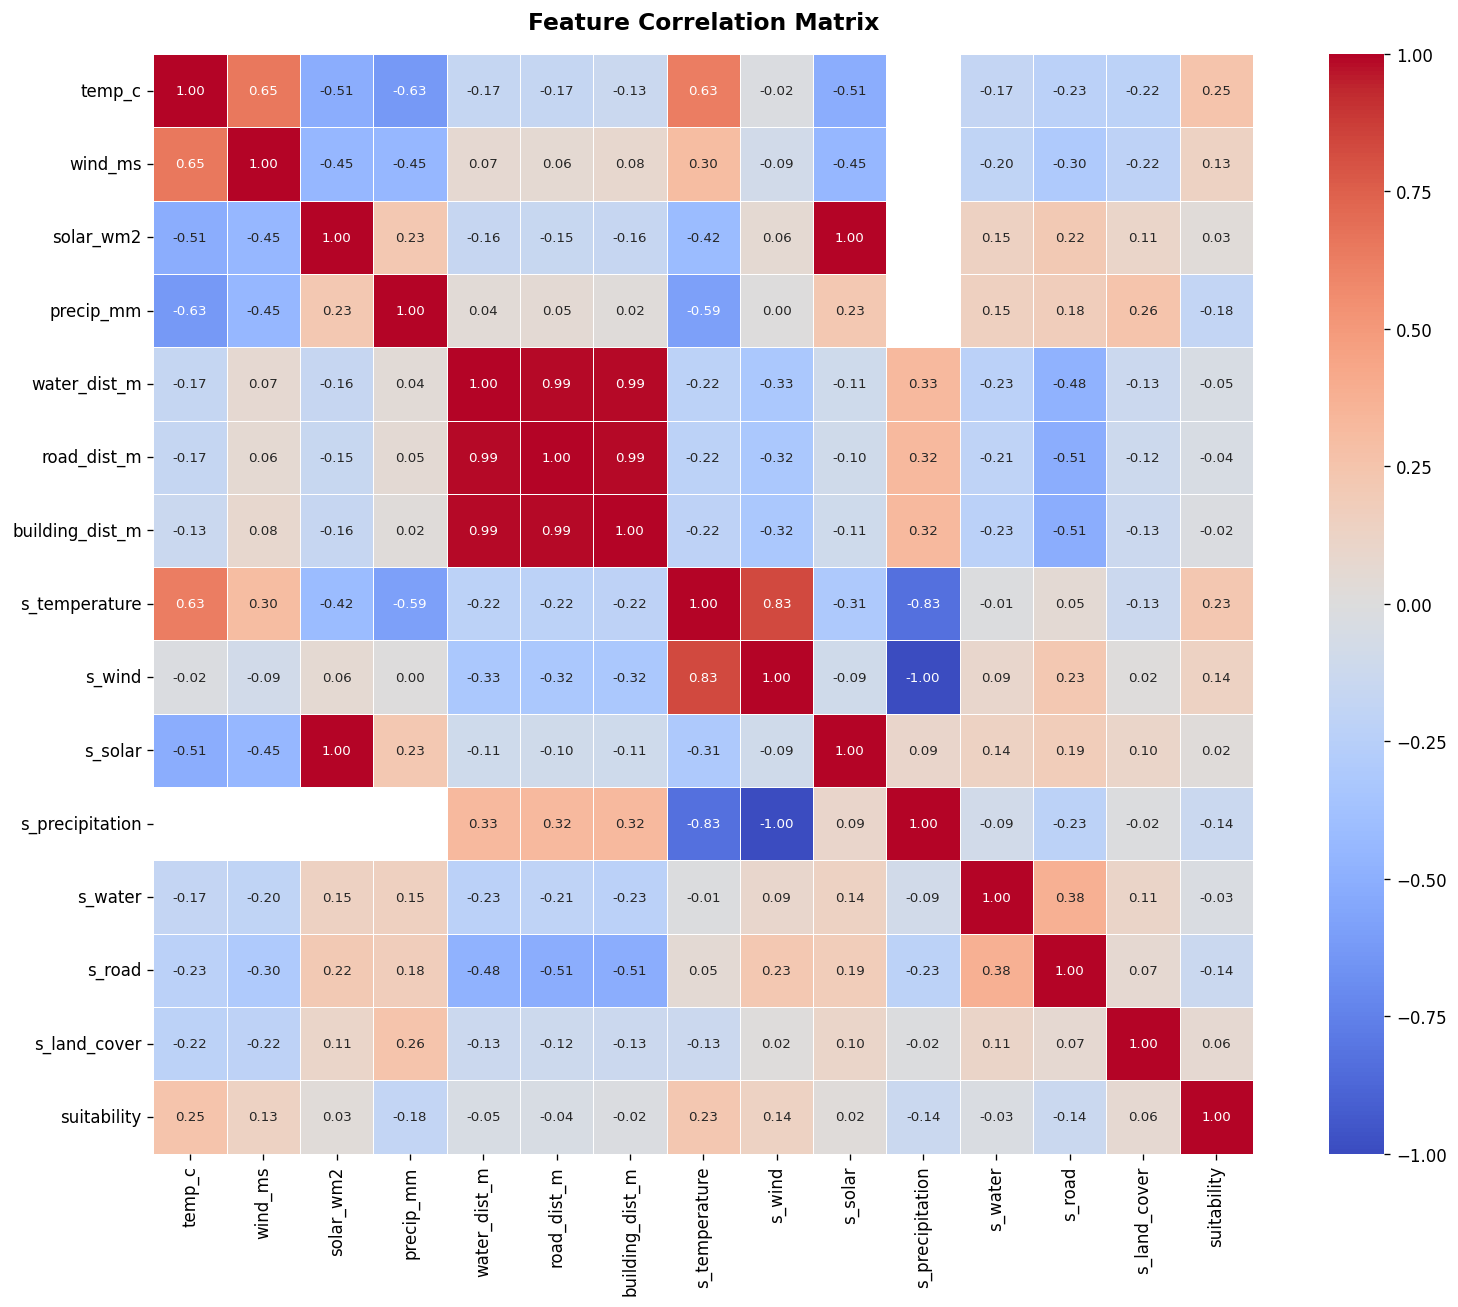

Saved → feature_correlation.png


In [51]:
corr_cols = ['temp_c', 'wind_ms', 'solar_wm2', 'precip_mm',
             'water_dist_m', 'road_dist_m', 'building_dist_m',
             's_temperature', 's_wind', 's_solar', 's_precipitation',
             's_water', 's_road', 's_land_cover', 'suitability']
corr_cols = [c for c in corr_cols if c in gdf.columns]

corr_df   = gdf[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 8},
            square=True)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_correlation.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print('Saved → feature_correlation.png')

### 6.7 Individual Score Distributions

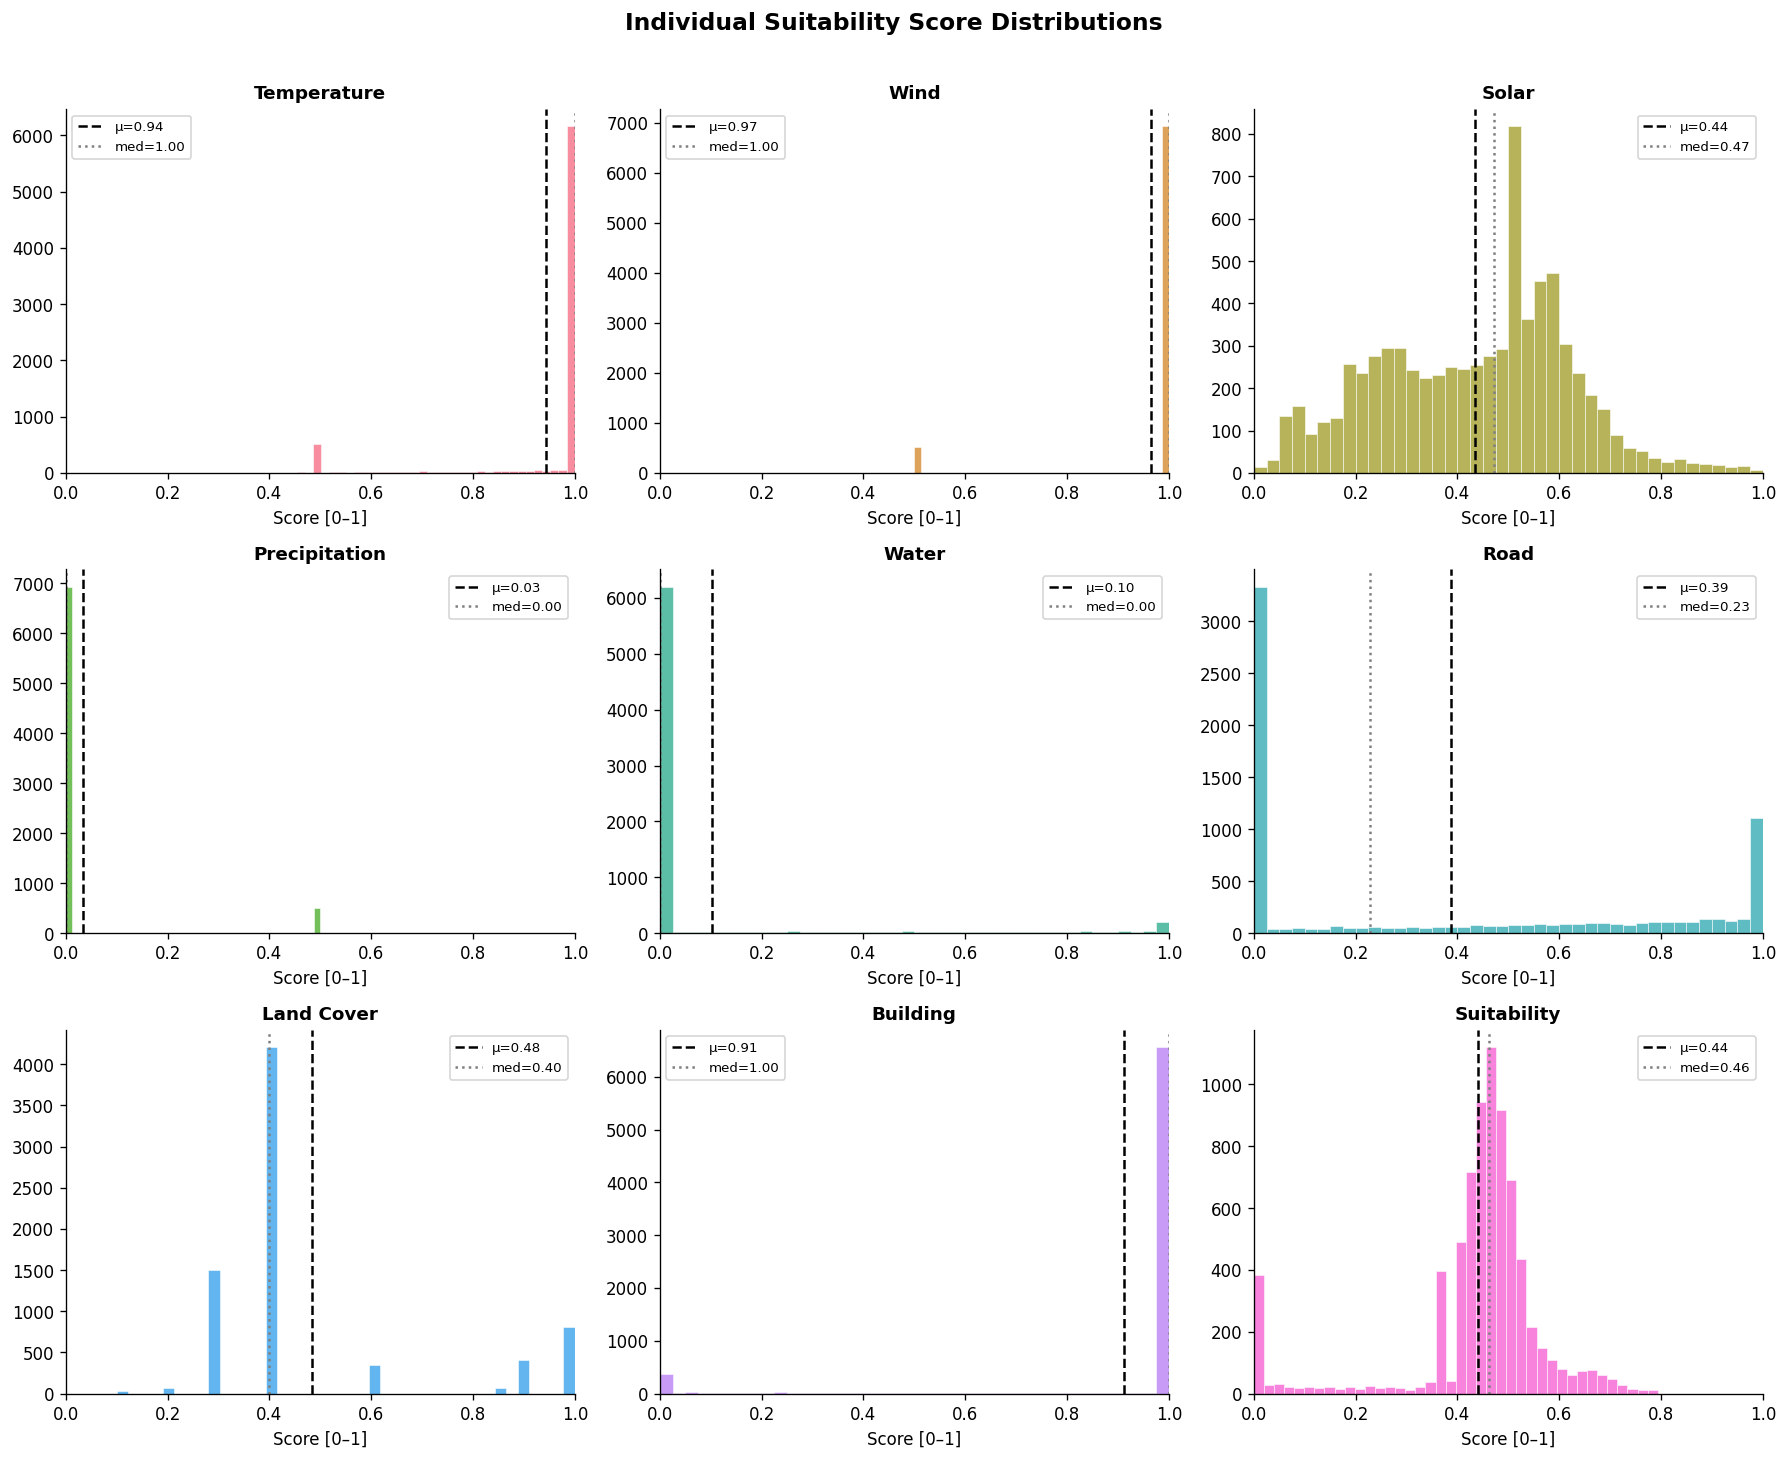

Saved → score_distributions.png


In [50]:
score_cols = ['s_temperature', 's_wind', 's_solar', 's_precipitation',
              's_water', 's_road', 's_land_cover', 's_building', 'suitability']
score_cols = [c for c in score_cols if c in gdf.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
colors = sns.color_palette('husl', len(score_cols))

for i, (col, color) in enumerate(zip(score_cols, colors)):
    ax = axes[i]
    data = gdf[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(), color='black',  linestyle='--', linewidth=1.5,
               label=f'μ={data.mean():.2f}')
    ax.axvline(data.median(), color='grey', linestyle=':', linewidth=1.5,
               label=f'med={data.median():.2f}')
    ax.set_xlim(0, 1)
    ax.set_title(col.replace('s_', '').replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Score [0–1]')
    ax.legend(fontsize=8)

# Hide unused axes
for j in range(len(score_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Individual Suitability Score Distributions', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'score_distributions.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print('Saved → score_distributions.png')

---
## 7. ML Model Training
### 7.1 Prepare Training Data with Synthetic Augmentation

In [49]:
def prepare_training_data(gdf, n_samples: int = 8000, random_state: int = 42):
    """
    Build training set:
      - Sample real grid points (physics score as target)
      - Augment with Gaussian noise for robustness
    """
    feat_available = [c for c in FEATURE_COLS if c in gdf.columns]
    data = gdf[feat_available + ['suitability']].dropna()

    # Stratified sampling across suitability quintiles
    data['_bin'] = pd.qcut(data['suitability'], q=5, labels=False, duplicates='drop')
    n_per_bin = n_samples // 5
    rng = np.random.RandomState(random_state)

    sampled_parts = []
    for b in data['_bin'].unique():
        chunk = data[data['_bin'] == b]
        n = min(n_per_bin, len(chunk))
        sampled_parts.append(chunk.sample(n, random_state=random_state))
    sampled = pd.concat(sampled_parts, ignore_index=True)

    X = sampled[feat_available].values
    y = sampled['suitability'].values

    # Gaussian augmentation
    noise_scale = 0.02
    X_aug = X + rng.normal(0, noise_scale, X.shape)
    X_aug = np.clip(X_aug, 0, None)
    y_aug = np.clip(y + rng.normal(0, 0.01, y.shape), 0, 1)

    X_all = np.vstack([X, X_aug])
    y_all = np.concatenate([y, y_aug])

    print(f'  Training set: {len(X_all):,} samples  ({len(feat_available)} features)')
    print(f'  Target range: [{y_all.min():.3f}, {y_all.max():.3f}]  '
          f'mean={y_all.mean():.3f}')
    return X_all, y_all, feat_available


print('Preparing training data…')
X_all, y_all, feat_names = prepare_training_data(
    gdf, n_samples=ML_CONFIG['n_samples'], random_state=ML_CONFIG['random_state'])

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=ML_CONFIG['test_size'],
    random_state=ML_CONFIG['random_state']
)
print(f'  Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Preparing training data…
  Training set: 13,860 samples  (15 features)
  Target range: [0.000, 0.794]  mean=0.445
  Train: 11,088  |  Test: 2,772


### 7.2 Train Random Forest & Gradient Boosting Ensemble

In [48]:
print('Training models…\n')
t0 = time.time()

# Random Forest
rf = RandomForestRegressor(
    n_estimators = ML_CONFIG['n_estimators'],
    max_depth    = ML_CONFIG['max_depth'],
    n_jobs       = -1,
    random_state = ML_CONFIG['random_state'],
)
rf.fit(X_train, y_train)
print(f'  ✅ Random Forest trained in {time.time()-t0:.1f}s')

t0 = time.time()
# Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators  = ML_CONFIG['n_estimators'],
    max_depth     = 5,
    learning_rate = 0.05,
    subsample     = 0.8,
    random_state  = ML_CONFIG['random_state'],
)
gb.fit(X_train, y_train)
print(f'  ✅ Gradient Boosting trained in {time.time()-t0:.1f}s')

# Ensemble: average of both
class EnsembleRegressor:
    def __init__(self, estimators, weights=None):
        self.estimators = estimators
        self.weights = weights or [1 / len(estimators)] * len(estimators)

    def predict(self, X):
        preds = np.stack([e.predict(X) for e in self.estimators], axis=1)
        return np.average(preds, axis=1, weights=self.weights)

    # Expose feature_importances_ from RF
    @property
    def feature_importances_(self):
        return self.estimators[0].feature_importances_


ensemble = EnsembleRegressor([rf, gb], weights=[0.55, 0.45])

# Store metadata for diagnostics
trained = {
    'rf':           rf,
    'gb':           gb,
    'ensemble':     ensemble,
    'X_test':       X_test,
    'y_test':       y_test,
    'X_train':      X_train,
    'y_train':      y_train,
    'feat_names':   feat_names,
}

# Save model
model_path = os.path.join(OUTPUT_DIR, 'bee_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(trained, f)
print(f'\n  💾 Model saved → {model_path}')

Training models…

  ✅ Random Forest trained in 12.2s
  ✅ Gradient Boosting trained in 24.0s

  💾 Model saved → C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs\bee_model.pkl


---
## 8. Model Evaluation & Diagnostics
### 8.1 Metrics Table

In [47]:
def compute_metrics(model, X_tr, y_tr, X_te, y_te, name):
    # Predictions (clipped between 0 and 1)
    y_pred_tr = np.clip(model.predict(X_tr), 0, 1)
    y_pred_te = np.clip(model.predict(X_te), 0, 1)
    
    # FIX: compute RMSE manually (no 'squared=False')
    rmse = np.sqrt(mean_squared_error(y_te, y_pred_te))
    
    return {
        'Model': name,
        'Train R²': round(r2_score(y_tr, y_pred_tr), 4),
        'Test R²': round(r2_score(y_te, y_pred_te), 4),
        'Test RMSE': round(rmse, 4),
        'Test MAE': round(mean_absolute_error(y_te, y_pred_te), 4),
    }

# ---- Compute Metrics ----
metrics_rows = [
    compute_metrics(rf,       X_train, y_train, X_test, y_test, 'Random Forest'),
    compute_metrics(gb,       X_train, y_train, X_test, y_test, 'Gradient Boosting'),
    compute_metrics(ensemble, X_train, y_train, X_test, y_test, 'Ensemble (RF+GB)'),
]

# ---- Create DataFrame ----
metrics_df = pd.DataFrame(metrics_rows)

# ---- Display Results ----
print('\n── Model Performance ──')

display(
    metrics_df.style
        .highlight_max(subset=['Train R²', 'Test R²'], color='#d4edda')
        .highlight_min(subset=['Test RMSE', 'Test MAE'], color='#d4edda')
        .format({
            'Train R²': '{:.4f}',
            'Test R²': '{:.4f}',
            'Test RMSE': '{:.4f}',
            'Test MAE': '{:.4f}'
        })
        .set_properties(**{'text-align': 'center'})
)


── Model Performance ──


,Model,Train R²,Test R²,Test RMSE,Test MAE
0,Random Forest,0.9995,0.9963,0.0088,0.0057
1,Gradient Boosting,0.9981,0.9971,0.0078,0.0052
2,Ensemble (RF+GB),0.9991,0.9969,0.0081,0.0053


### 8.2 Cross-Validation

Running 5-fold cross-validation (RF)…
  CV R² scores : [0.9987 0.9902 0.9193 0.9958 0.9318]
  Mean ± Std   : 0.9672 ± 0.0343


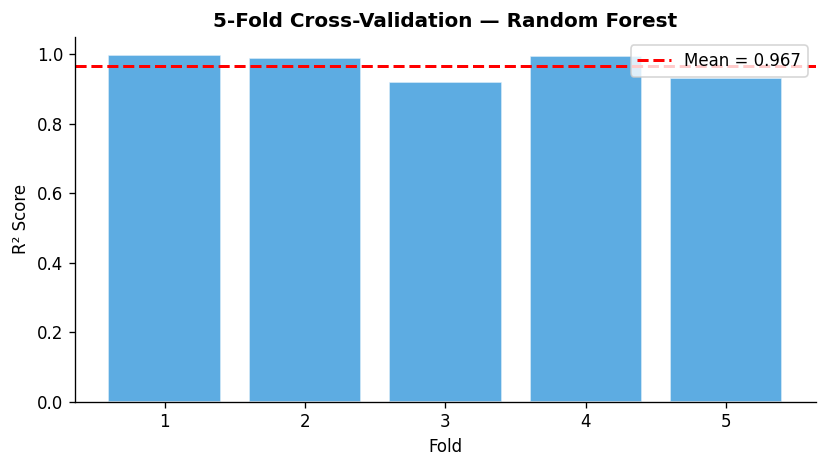

Saved → cross_validation.png


In [46]:
print('Running 5-fold cross-validation (RF)…')
cv_scores = cross_val_score(
    rf, X_all, y_all, cv=5, scoring='r2', n_jobs=-1)
print(f'  CV R² scores : {cv_scores.round(4)}')
print(f'  Mean ± Std   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='#3498db', alpha=0.8, edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.8,
           label=f'Mean = {cv_scores.mean():.3f}')
ax.set_xlabel('Fold')
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross-Validation — Random Forest', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cross_validation.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved → cross_validation.png')

### 8.3 Feature Importance

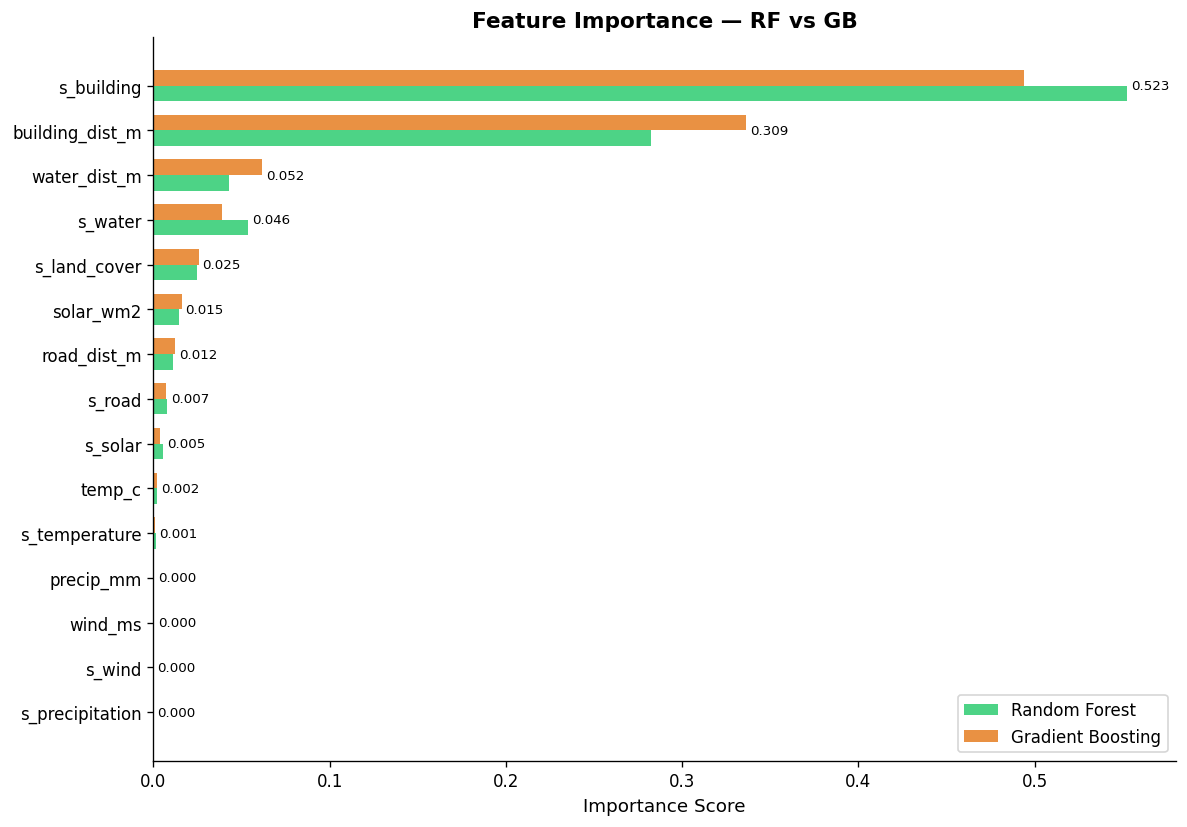

Saved → feature_importance.png


In [45]:
imp_rf = rf.feature_importances_
imp_gb = gb.feature_importances_
imp_df = pd.DataFrame({
    'Feature':          feat_names,
    'RF Importance':    imp_rf,
    'GB Importance':    imp_gb,
    'Mean Importance':  (imp_rf + imp_gb) / 2,
}).sort_values('Mean Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
x     = range(len(imp_df))
width = 0.35
bars1 = ax.barh([i - width/2 for i in x], imp_df['RF Importance'],
                height=width, color='#2ecc71', alpha=0.85, label='Random Forest')
bars2 = ax.barh([i + width/2 for i in x], imp_df['GB Importance'],
                height=width, color='#e67e22', alpha=0.85, label='Gradient Boosting')
ax.set_yticks(x)
ax.set_yticklabels(imp_df['Feature'], fontsize=10)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Feature Importance — RF vs GB', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Annotate with mean value
for i, row in enumerate(imp_df.itertuples()):
    ax.text(max(row[2], row[3]) + 0.002, i, f'{row[4]:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved → feature_importance.png')

### 8.4 Residual Analysis

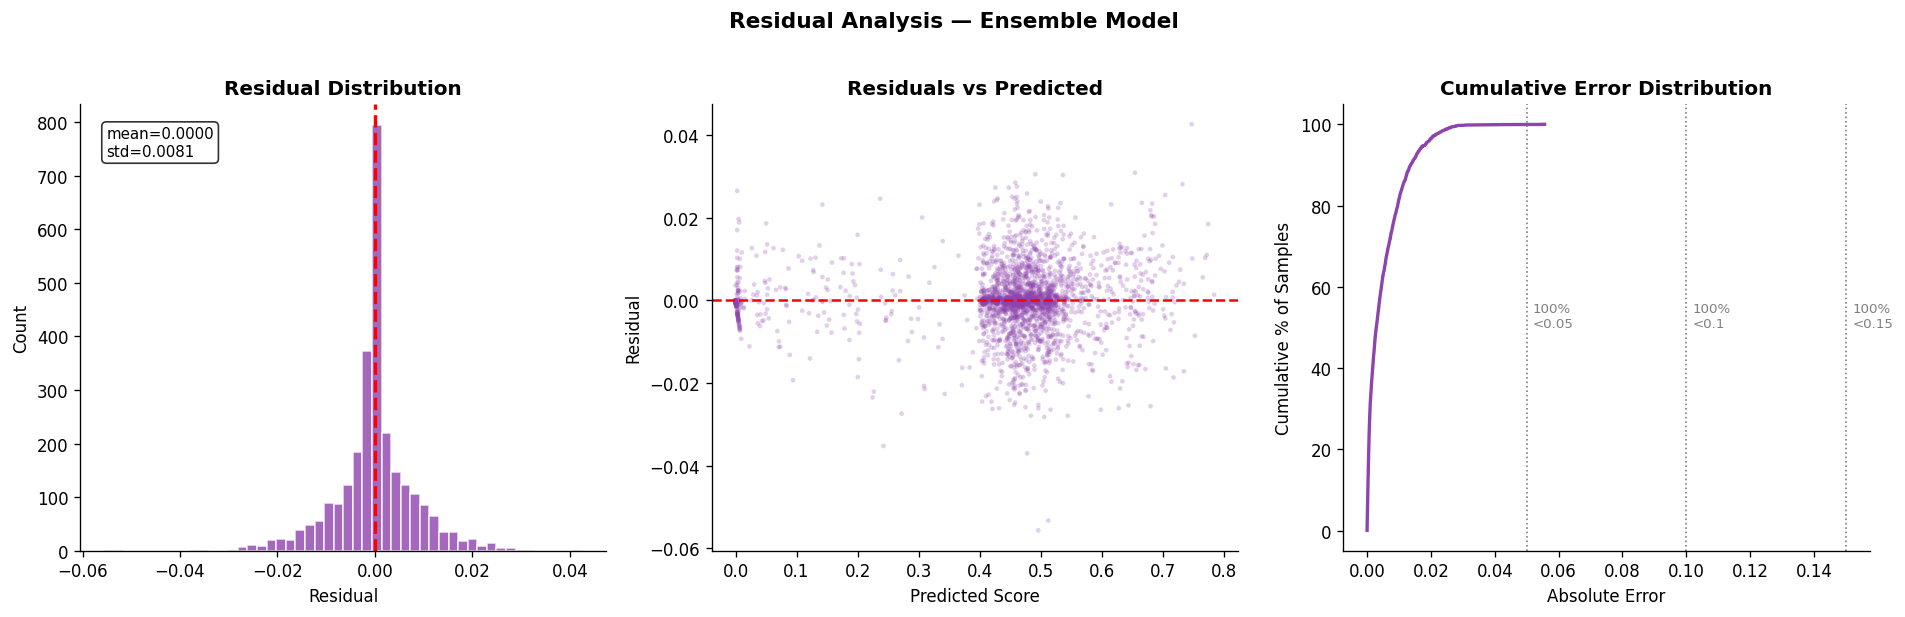

Saved → residual_analysis.png


In [44]:
residuals = y_test - y_pred_ensemble

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residual distribution
axes[0].hist(residuals, bins=50, color='#8e44ad', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].text(0.05, 0.95, f'mean={residuals.mean():.4f}\nstd={residuals.std():.4f}',
             transform=axes[0].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Residuals vs predicted
axes[1].scatter(y_pred_ensemble, residuals, alpha=0.25, s=8, color='#8e44ad', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')

# Cumulative error
abs_err = np.abs(residuals)
sorted_err = np.sort(abs_err)
cum_pct = np.arange(1, len(sorted_err) + 1) / len(sorted_err) * 100
axes[2].plot(sorted_err, cum_pct, color='#8e44ad', linewidth=2)
for thr in [0.05, 0.10, 0.15]:
    pct = (abs_err <= thr).mean() * 100
    axes[2].axvline(thr, color='grey', linestyle=':', linewidth=1)
    axes[2].text(thr + 0.002, 50, f'{pct:.0f}%\n<{thr}', fontsize=8, color='grey')
axes[2].set_xlabel('Absolute Error')
axes[2].set_ylabel('Cumulative % of Samples')
axes[2].set_title('Cumulative Error Distribution', fontweight='bold')

plt.suptitle('Residual Analysis — Ensemble Model', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'residual_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved → residual_analysis.png')

---
## 9. Predict Suitability on Full Grid

In [43]:
print('Predicting ML suitability on full grid…')
feat_available = [c for c in FEATURE_COLS if c in gdf.columns]
X_full = gdf[feat_available].values

# Handle any remaining NaNs → median imputation
col_medians = np.nanmedian(X_full, axis=0)
nan_mask    = np.isnan(X_full)
X_full_imp  = X_full.copy()
for j in range(X_full.shape[1]):
    X_full_imp[nan_mask[:, j], j] = col_medians[j]

gdf['ml_suitability'] = np.clip(ensemble.predict(X_full_imp), 0, 1)

# Summary stats by threshold
thresh    = ML_CONFIG['optimal_threshold']
hi_thresh = ML_CONFIG['high_threshold']
n_total   = len(gdf)
n_opt     = (gdf['ml_suitability'] >= thresh).sum()
n_hi      = (gdf['ml_suitability'] >= hi_thresh).sum()
n_good    = ((gdf['ml_suitability'] >= 0.50) & (gdf['ml_suitability'] < thresh)).sum()

print(f'\n  Grid points   : {n_total:,}')
print(f'  🔴 Prime (≥{hi_thresh}) : {n_hi:,}  ({100*n_hi/n_total:.1f}%)')
print(f'  🟠 Optimal (≥{thresh}) : {n_opt:,}  ({100*n_opt/n_total:.1f}%)')
print(f'  🟡 Good (0.5–{thresh}): {n_good:,}  ({100*n_good/n_total:.1f}%)')
print(f'  Mean score    : {gdf["ml_suitability"].mean():.3f}')

Predicting ML suitability on full grid…

  Grid points   : 7,440
  🔴 Prime (≥0.8) : 0  (0.0%)
  🟠 Optimal (≥0.65) : 268  (3.6%)
  🟡 Good (0.5–0.65): 1,710  (23.0%)
  Mean score    : 0.445


### 9.1 Suitability Score Distribution

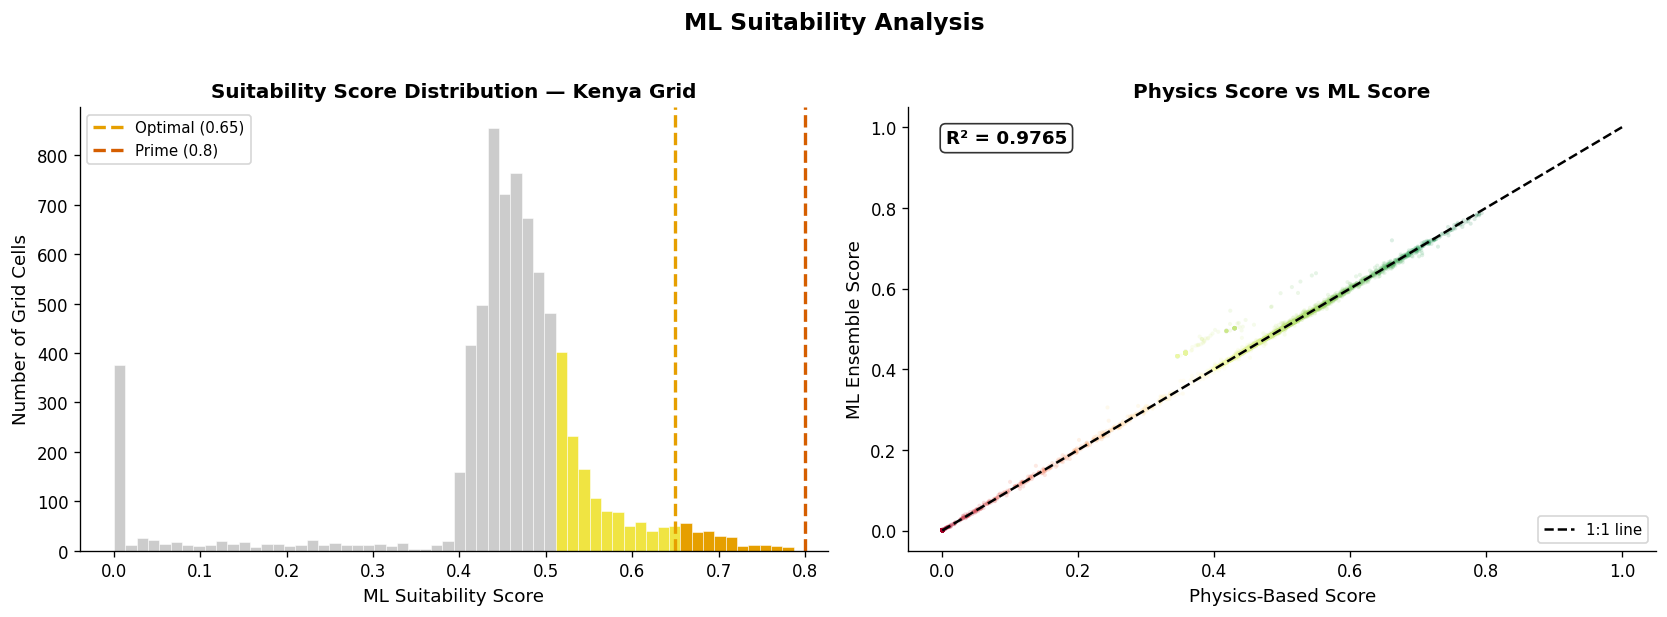

Saved → suitability_analysis.png


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
n, bins, patches = ax.hist(gdf['ml_suitability'], bins=60, edgecolor='white', linewidth=0.3)
# Colour bars by zone
for patch, left in zip(patches, bins[:-1]):
    if left >= 0.80:  patch.set_facecolor('#d55e00')
    elif left >= 0.65: patch.set_facecolor('#e69f00')
    elif left >= 0.50: patch.set_facecolor('#f0e442')
    else:              patch.set_facecolor('#cccccc')

for t, color, label in [
    (thresh,    '#e69f00', f'Optimal ({thresh})'),
    (hi_thresh, '#d55e00', f'Prime ({hi_thresh})'),
]:
    ax.axvline(t, color=color, linestyle='--', linewidth=2, label=label)

ax.set_xlabel('ML Suitability Score', fontsize=11)
ax.set_ylabel('Number of Grid Cells', fontsize=11)
ax.set_title('Suitability Score Distribution — Kenya Grid', fontweight='bold')
ax.legend(fontsize=9)

# Physics vs ML scatter
ax = axes[1]
ax.scatter(gdf['suitability'], gdf['ml_suitability'],
           alpha=0.15, s=6, c=gdf['ml_suitability'], cmap='RdYlGn', edgecolors='none')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='1:1 line')
ax.set_xlabel('Physics-Based Score', fontsize=11)
ax.set_ylabel('ML Ensemble Score', fontsize=11)
ax.set_title('Physics Score vs ML Score', fontweight='bold')
r2_comp = r2_score(gdf['suitability'].values, gdf['ml_suitability'].values)
ax.text(0.05, 0.95, f'R² = {r2_comp:.4f}', transform=ax.transAxes,
        va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.legend(fontsize=9)

plt.suptitle('ML Suitability Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'suitability_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved → suitability_analysis.png')

---
## 10. Results Export
### 10.1 Full Grid CSV

In [41]:
export_cols = [
    'lat', 'lon',
    'temp_c', 'wind_ms', 'solar_wm2', 'precip_mm',
    'water_dist_m', 'road_dist_m', 'building_dist_m',
    's_temperature', 's_wind', 's_solar', 's_precipitation',
    's_water', 's_road', 's_land_cover', 's_building',
    'suitability', 'ml_suitability',
]
export_cols = [c for c in export_cols if c in gdf.columns]

csv_path = os.path.join(OUTPUT_DIR, 'kenya_bee_suitability.csv')
gdf[export_cols].to_csv(csv_path, index=False, float_format='%.4f')
print(f'✅ Full grid exported → {csv_path}')
print(f'   Rows: {len(gdf):,}  |  Columns: {len(export_cols)}')
gdf[export_cols].describe().round(3)

✅ Full grid exported → C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs\kenya_bee_suitability.csv
   Rows: 7,440  |  Columns: 19


,lat,lon,temp_c,wind_ms,solar_wm2,precip_mm,water_dist_m,road_dist_m,building_dist_m,s_temperature,s_wind,s_solar,s_precipitation,s_water,s_road,s_land_cover,s_building,suitability,ml_suitability
count,7440.000,7440.000,6930.000,6930.000,6930.000,6930.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000,7440.000
mean,-0.020,37.910,24.870,3.144,8.952,15140.703,33139.978,32978.517,36433.909,0.944,0.966,0.435,0.034,0.102,0.388,0.483,0.912,0.440,0.445
std,2.685,2.309,3.583,1.429,1.208,9585.782,55217.318,56890.370,56810.715,0.145,0.126,0.186,0.126,0.259,0.410,0.229,0.263,0.140,0.138
min,-4.620,33.960,13.568,0.401,6.240,3825.684,3.075,13.117,0.884,0.357,0.500,0.000,0.000,0.000,0.000,0.100,0.000,0.000,0.000
25%,-2.320,35.935,22.352,2.053,7.966,10155.410,3186.155,2591.878,3650.311,1.000,1.000,0.284,0.000,0.000,0.000,0.400,1.000,0.422,0.434
50%,-0.020,37.910,26.032,3.268,9.062,12466.550,9185.947,7944.335,12856.994,1.000,1.000,0.472,0.000,0.000,0.228,0.400,1.000,0.463,0.464
75%,2.280,39.885,27.785,4.012,9.870,16843.078,33537.888,33770.967,40593.315,1.000,1.000,0.571,0.000,0.000,0.823,0.400,1.000,0.502,0.502
max,4.580,41.860,30.714,6.744,12.541,160280.518,339998.067,345129.797,353617.390,1.000,1.000,1.000,0.500,1.000,1.000,1.000,1.000,0.794,0.787


### 10.2 Top 20 Recommended Locations

In [40]:
top20_cols = ['lat', 'lon', 'ml_suitability', 'suitability',
              'temp_c', 'wind_ms', 'precip_mm', 'water_dist_m',
              'road_dist_m', 's_temperature', 's_precipitation', 's_water']
top20_cols = [c for c in top20_cols if c in gdf.columns]

top20 = (gdf.nlargest(20, 'ml_suitability')[top20_cols]
         .reset_index(drop=True))
top20.index += 1  # 1-based ranking

top20_path = os.path.join(OUTPUT_DIR, 'top20_locations.csv')
top20.to_csv(top20_path, float_format='%.4f')

print('\n🏆 Top 20 Recommended Beekeeping Locations:')
display(top20.style
        .background_gradient(subset=['ml_suitability'], cmap='RdYlGn')
        .format({'ml_suitability': '{:.3f}', 'suitability': '{:.3f}',
                 'temp_c': '{:.1f}°C', 'wind_ms': '{:.1f} m/s',
                 'precip_mm': '{:.0f} mm', 'water_dist_m': '{:.0f} m',
                 'road_dist_m': '{:.0f} m', 'lat': '{:.4f}', 'lon': '{:.4f}'})
        .set_caption('Top 20 Grid Cells by ML Suitability Score'))
print(f'\n✅ Saved → {top20_path}')


🏆 Top 20 Recommended Beekeeping Locations:


,lat,lon,ml_suitability,suitability,temp_c,wind_ms,precip_mm,water_dist_m,road_dist_m,s_temperature,s_precipitation,s_water
1,-0.3200,38.2600,0.787,0.794,25.9°C,2.4 m/s,13963 mm,291 m,639 m,1.000000,0.000000,1.000000
2,0.0800,36.0600,0.785,0.789,20.2°C,0.9 m/s,27064 mm,639 m,302 m,1.000000,0.000000,0.850657
3,-0.8200,37.2600,0.784,0.790,20.7°C,1.1 m/s,15911 mm,622 m,62 m,1.000000,0.000000,0.861401
4,-1.3200,36.9600,0.784,0.787,19.4°C,2.3 m/s,13815 mm,36 m,947 m,0.939249,0.000000,1.000000
5,0.3800,35.8600,0.781,0.790,22.1°C,0.7 m/s,22650 mm,71 m,2372 m,1.000000,0.000000,1.000000
6,-0.8200,37.7600,0.781,0.785,23.0°C,2.0 m/s,12998 mm,529 m,1848 m,1.000000,0.000000,0.919509
7,2.6800,35.3600,0.780,0.785,28.3°C,2.0 m/s,12811 mm,154 m,1095 m,1.000000,0.000000,1.000000
8,0.0800,35.0600,0.774,0.776,19.6°C,0.6 m/s,29333 mm,95 m,702 m,0.958712,0.000000,1.000000
9,-0.0200,37.8600,0.774,0.774,22.7°C,1.9 m/s,14279 mm,641 m,892 m,1.000000,0.000000,0.849142
10,-1.7200,36.6600,0.773,0.774,21.3°C,2.1 m/s,15341 mm,474 m,1824 m,1.000000,0.000000,0.953963



✅ Saved → C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs\top20_locations.csv


### 10.3 Zonal Summary

In [36]:
def zone_label(score):
    if score >= 0.80: return '🔴 Prime'
    if score >= 0.65: return '🟠 Optimal'
    if score >= 0.50: return '🟡 Good'
    if score >= 0.35: return '🔵 Fair'
    return '⚫ Poor'

gdf['zone'] = gdf['ml_suitability'].apply(zone_label)

zone_summary = (gdf.groupby('zone')
                .agg(count=('ml_suitability', 'count'),
                     mean_ml=('ml_suitability', 'mean'),
                     mean_temp=('temp_c', 'mean'),
                     mean_precip=('precip_mm', 'mean'),
                     mean_water_dist=('water_dist_m', 'mean'))
                .assign(pct=lambda df: 100 * df['count'] / df['count'].sum())
                .sort_values('mean_ml', ascending=False)
                .round(2))

print('\n📊 Zonal Summary:')
display(zone_summary)


📊 Zonal Summary:


,count,mean_ml,mean_temp,mean_precip,mean_water_dist,pct
zone,,,,,,
🟠 Optimal,268,0.69,24.18,17490.51,555.91,3.60
🟡 Good,1710,0.54,24.59,16159.11,9404.70,22.98
🔵 Fair,4739,0.45,25.61,13480.18,48247.25,63.70
⚫ Poor,723,0.08,21.35,21856.34,2332.91,9.72


---
## 11. Interactive Map Generation
### 11.1 Map 1 — Full Feature Dashboard

In [37]:
MAP_CENTER = [-0.5, 37.9]
MAP_ZOOM   = 6

SCORE_CMAP = LinearColormap(
    colors=['#d73027','#fc8d59','#fee090','#e0f3f8','#91bfdb','#4575b4'],
    vmin=0.0, vmax=1.0,
    caption='Suitability Score (0 = poor → 1 = excellent)',
)


def _popup_html(row) -> str:
    fields = {
        'temp_c':       ('🌡 Temperature', '°C'),
        'wind_ms':      ('💨 Wind speed',  ' m/s'),
        'solar_wm2':    ('☀ Solar rad.',   ' W/m²'),
        'precip_mm':    ('🌧 Precip.',     ' mm/yr'),
        'water_dist_m': ('💧 Water dist.', ' m'),
        'road_dist_m':  ('🛣 Road dist.',  ' m'),
    }
    html = ''
    for col, (lbl, unit) in fields.items():
        if col in row.index and pd.notna(row[col]):
            html += f'<b>{lbl}:</b> {row[col]:.1f}{unit}<br>'
    return html


def _base_map(title):
    m = folium.Map(location=MAP_CENTER, zoom_start=MAP_ZOOM, tiles=None)
    folium.TileLayer('CartoDB positron', name='Light',
                     attr='© OpenStreetMap | © CartoDB').add_to(m)
    folium.TileLayer('CartoDB dark_matter', name='Dark',
                     attr='© OpenStreetMap | © CartoDB').add_to(m)
    folium.TileLayer('OpenStreetMap', name='OpenStreetMap',
                     attr='© OpenStreetMap').add_to(m)
    Fullscreen().add_to(m)
    MiniMap(toggle_display=True, tile_layer='CartoDB positron').add_to(m)
    MousePosition(position='bottomleft', separator=' | ', prefix='Lat/Lon:').add_to(m)
    m.get_root().html.add_child(folium.Element(f"""
    <div style="position:fixed;top:12px;left:55px;z-index:9999;
                background:rgba(255,255,255,0.9);padding:8px 14px;
                border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,0.25);
                font-family:'Segoe UI',sans-serif;font-size:15px;
                font-weight:700;color:#333;">🐝 {title}</div>"""))
    return m


print('Building main dashboard map…')
m1 = _base_map('Bee Optimal Placement — Full Dashboard')

# ML suitability circles (all points)
fg_all = folium.FeatureGroup(name='ML Suitability (all)', show=True)
cmap_fn = cm.RdYlGn
for _, row in gdf.iterrows():
    sc = float(row['ml_suitability'])
    r, g, b, _ = cmap_fn(sc)
    hex_c = '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5, color=hex_c, fill=True, fill_color=hex_c,
        fill_opacity=0.5, weight=0,
        popup=folium.Popup(
            f'<b>Score:</b> {sc:.3f}<br><b>Lat:</b> {row["lat"]:.3f}  '
            f'<b>Lon:</b> {row["lon"]:.3f}<br>' + _popup_html(row), max_width=280),
        tooltip=f'Score: {sc:.2f}',
    ).add_to(fg_all)
fg_all.add_to(m1)

# Heat map
heat_data = gdf[gdf['ml_suitability'] > 0][['lat','lon','ml_suitability']].values.tolist()
HeatMap(heat_data, name='Suitability Heat Map', min_opacity=0.3,
        radius=18, blur=15,
        gradient={0.0:'blue', 0.4:'lime', 0.7:'yellow', 1.0:'red'},
        show=False).add_to(m1)

# Optimal zones
opt = gdf[gdf['ml_suitability'] >= thresh]
fg_opt = folium.FeatureGroup(name=f'✅ Optimal Zones (≥{thresh})', show=True)
for _, row in opt.iterrows():
    sc = float(row['ml_suitability'])
    folium.CircleMarker(
        location=[row['lat'], row['lon']], radius=9,
        color='#ff6600', fill=True, fill_color='#ff9900', fill_opacity=0.75, weight=2,
        popup=folium.Popup(f'<b>⭐ OPTIMAL</b><br>Score: {sc:.3f}<br>' + _popup_html(row),
                           max_width=280),
        tooltip=f'⭐ {sc:.2f}',
    ).add_to(fg_opt)
fg_opt.add_to(m1)

# Highly optimal
hi_opt = gdf[gdf['ml_suitability'] >= hi_thresh]
fg_hi = folium.FeatureGroup(name=f'🌟 Prime Zones (≥{hi_thresh})', show=True)
for _, row in hi_opt.iterrows():
    sc = float(row['ml_suitability'])
    folium.CircleMarker(
        location=[row['lat'], row['lon']], radius=12,
        color='#cc0000', fill=True, fill_color='#ff0000', fill_opacity=0.85, weight=2.5,
        popup=folium.Popup(f'<b>🌟 PRIME</b><br>Score: {sc:.3f}<br>' + _popup_html(row),
                           max_width=280),
        tooltip=f'🌟 {sc:.2f}',
    ).add_to(fg_hi)
fg_hi.add_to(m1)

SCORE_CMAP.add_to(m1)
folium.LayerControl(collapsed=False).add_to(m1)

map1_path = os.path.join(OUTPUT_DIR, 'main_map.html')
m1.save(map1_path)
print(f'✅ Main map saved → {map1_path}')

Building main dashboard map…
✅ Main map saved → C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs\main_map.html


### 11.2 Map 2 — Optimal Areas (Clean View)

In [38]:
OPTIMAL_CMAP = LinearColormap(
    colors=['#ffffb2','#fecc5c','#fd8d3c','#e31a1c'],
    vmin=0.6, vmax=1.0,
    caption='Optimal Zone Score (≥0.50 shown)',
)

print('Building optimal-areas map…')
m2 = _base_map('Bee Placement — Optimal Areas')

TIERS = [
    (0.50, 0.64, '#f0e442', '🟡 Good (0.50–0.64)',    8,  0.65),
    (0.65, 0.79, '#e69f00', '🟠 Optimal (0.65–0.79)', 11, 0.80),
    (0.80, 1.00, '#d55e00', '🔴 Prime (≥0.80)',        14, 0.90),
]

for lo, hi, colour, label, radius, opacity in TIERS:
    sub = gdf[(gdf['ml_suitability'] >= lo) & (gdf['ml_suitability'] < hi)]
    if len(sub) == 0:
        continue
    fg = folium.FeatureGroup(name=label, show=True)
    for _, row in sub.iterrows():
        sc = float(row['ml_suitability'])
        tier = '🔴 Prime' if sc >= 0.80 else ('🟠 Optimal' if sc >= 0.65 else '🟡 Good')
        popup_html = f"""
        <div style="font-family:'Segoe UI',sans-serif;font-size:13px;">
          <h4 style="margin:0 0 6px;color:#8B4513;">🐝 {tier}</h4>
          <b>ML Score:</b> {sc:.3f}<br>
          <b>Coords:</b> {row['lat']:.4f}°, {row['lon']:.4f}°<br>
          <hr style="margin:5px 0;">
          {_popup_html(row)}
        </div>"""
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=radius, color=colour, fill=True,
            fill_color=colour, fill_opacity=opacity, weight=1.5,
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f'{label.split()[0]} | {sc:.2f}',
        ).add_to(fg)
    fg.add_to(m2)

# Marker cluster view
opt_all = gdf[gdf['ml_suitability'] >= 0.50].copy()
if len(opt_all):
    cluster = MarkerCluster(name='📍 Clustered view', show=False)
    for _, row in opt_all.iterrows():
        sc = float(row['ml_suitability'])
        folium.Marker(
            location=[row['lat'], row['lon']],
            icon=folium.Icon(
                color='red' if sc >= 0.80 else ('orange' if sc >= 0.65 else 'beige'),
                icon='home', prefix='fa'),
            tooltip=f'Score: {sc:.2f}',
        ).add_to(cluster)
    cluster.add_to(m2)

# Stats panel
stats_html = f"""
<div style="position:fixed;top:60px;right:10px;z-index:9999;
            background:rgba(255,255,255,0.95);padding:12px 16px;
            border-radius:10px;box-shadow:0 2px 10px rgba(0,0,0,0.3);
            font-family:'Segoe UI',sans-serif;font-size:12px;
            min-width:210px;border-top:4px solid #e69f00;">
  <b style="font-size:13px;">📊 Analysis Summary</b><br><br>
  <b>Total grid cells:</b> {n_total:,}<br>
  <b>🔴 Prime zones:</b> {n_hi:,} ({100*n_hi/n_total:.1f}%)<br>
  <b>🟠 Optimal zones:</b> {n_opt:,} ({100*n_opt/n_total:.1f}%)<br>
  <b>🟡 Good zones:</b> {n_good:,} ({100*n_good/n_total:.1f}%)<br>
  <b>Mean score:</b> {gdf['ml_suitability'].mean():.3f}<br>
  <hr style="border-color:#eee;margin:7px 0;">
  <small style="color:#888;">Grid res: {GRID_RESOLUTION}° (~{GRID_RESOLUTION*111:.0f} km)</small>
</div>"""
m2.get_root().html.add_child(folium.Element(stats_html))

OPTIMAL_CMAP.add_to(m2)
folium.LayerControl(collapsed=False).add_to(m2)

map2_path = os.path.join(OUTPUT_DIR, 'optimal_areas_map.html')
m2.save(map2_path)
print(f'✅ Optimal areas map saved → {map2_path}')

Building optimal-areas map…
✅ Optimal areas map saved → C:\Users\ZUPLO\Desktop\BEE PROJECT\outputs\optimal_areas_map.html
